# Gaussian Processes

The purpose of this notebook is to provide an introduction to Gaussian Processes (GPs) and its main properties.

Before diving into the theory, let's start by loading the libraries

-  `matplotlib`  
-  [`aleatory`](https://github.com/quantgirluk/aleatory) 
  
  
together with the style sheet [Quant-Pastel Light](https://github.com/quantgirluk/matplotlib-stylesheets). 

These tools will help us to make insightful visualisations.

In [1]:
import matplotlib.pyplot as plt

mystyle = "https://raw.githubusercontent.com/quantgirluk/matplotlib-stylesheets/main/quant-pastel-light.mplstyle"
plt.style.use(mystyle)

%config InlineBackend.figure_format='retina'
# plt.rcParams["figure.figsize"] = (12, 6)

## Introduction

In probability theory and statistics, a Gaussian process is a stochastic process, such that every finite collection of those random variables has a **multivariate normal distribution**. The distribution of a Gaussian process is the joint distribution of all those (infinitely many) random variables, and as such, it is a distribution over functions with a continuous domain, e.g. time or space.

The concept of Gaussian processes is named after [Carl Friedrich Gauss](https://en.wikipedia.org/wiki/Carl_Friedrich_Gauss) because it is based on the notion of the Gaussian distribution (normal distribution). Gaussian processes can be seen as an infinite-dimensional generalization of multivariate normal distributions.


Gaussian Processes (GPs) are one of the most elegant ideas in probabilistic modelling:  instead of learning *parameters*, we learn a **distribution over functions**. They are widely used in:
- Regression  
- Bayesian Optimisation  
- Spatial Modelling  
- Uncertainty Quantification  


## Definition

A Gaussian Process (GP) is a stochastic process $X = \{X_t :  t \in \Tau \}$ where $\Tau \in \mathbb{R}^d$, such that  for every finite set of indices $\{t_1, \cdots, t_n\}$ in the index set $\Tau$, the random vector

$$X_{t_1, \cdots, t_n} = (X_{t_1}, \cdots, X_{t_n})^{T}$$

has a  multivariate Gaussian distribution,  with mean and covariance given by 

$$m (t_i) = E[X_{t_i}], \qquad K(t_i, t_j) = Cov(X_{t_i}, X_{t_j}).$$

That is

$$X_{t_1, \cdots, t_n} \sim \mathcal{N}(m, K)$$

A Gaussian Process (GP) is then fully specified by two functions, namely

- a Mean function $m(t) = E[X_t]$
- a Covariance function $k(t, s)=  E[(X_s- E[X_s])(X_t- E[X_t])]$

where the covariance function must be symmetric, and positive semi-definite, i.e. for any finite $\{t_i\}$ and $\{c_i\} \subset \mathbb{R}$:

$$\sum_{i, j} c_i, c_j k(t_i, t_j) \geq 0.$$

Hereafter we are gong to use the notation $X \sim \mathcal{GP}(m, k)$.

```{note}


- The covariance function $k(t, s)$ is often called _kernel_ function 
- A GP is called  _centered_ if $m(t) =0,$ for all $t\in \Tau$

```


**Theorem.** A stochastic process $X = \{X_t :  t \in \Tau \}$ is a Gaussian process if an only if every finite linear combination of its values is a Gaussian random variable. 


The linear combination characterisation is very useful in practice because:

- It reduces checking joint Gaussianity to checking scalar random variables
- It makes closure properties immediate: sums, differences, and integrals of GP-distributed processes are again Gaussian
- It directly motivates the kernel/covariance structure as the object controlling the variance of every possible projection $c^{T} X$


### Marginal Distributions

By definition, the marginal distributions of a Gaussian process are Gaussian. That is, for any $t \in \Tau$, the random variable $X_t$ is Gaussian with mean $m(t)$ and variance $k(t, t)$:

$$X_t \sim \mathcal{N}(m(t), k(t, t)).$$



### Examples

1. A Brownian motion $W = \{W_t : t\geq 0\}$ is a centered GP with covariance function 

$$k(s, t) = \min\{s, t\}$$

2. An Orstein-Uhlenbeck process $X = X(\theta, \sigma)$, starting at $X_0=x_0$, is a centered GP with covariance function

$$k(s,t) = e^{-(s+t)} \cdot \dfrac{e^{2\min(s, t)}-1}{2}$$

3. A Brownian Bridge $B= {B_t : t\in [0,1]}$ is a centered GP with covariance function

$$k(s,t) = \min(s,t) - st$$



### Counterexamples

1. A Geometric Browanian motion is not a Gaussian process as its marginal distributions are log-normal, not Gaussian.

2. A CIR process is not a Gaussian process as its marginal distributions are scaled Chi-square,  not Gaussian.

3. A Bessel process is not a Gaussian process as its marginal distributions are non-central chi, not Gaussian.

## Simulation 

In order to simulate paths from a Gaussian process $X \sim \mathcal{GP}(m, k)$, we need to set a discrete partition over an interval for the simulation to take place. 

For simplicity, we are going to consider an equidistant partition of size $n$ over $[0,T]$, i.e.:
\begin{equation*}
t_i = \frac{i}{n-1} T \qquad  \hbox{for } i = 0, \cdots, n-1.
\end{equation*}

By definition, the joint distribution of 

$$X_{t_1, \cdots, t_n} = (X_{t_1}, \cdots, X_{t_n})^{T}$$

is multivariate Gaussian. Therefore, we can get a path by sampling from a multivariate normal distribution with mean vector $\mu = [m(t_1), \cdots, m(t_n)]$ and covariance matrix 

$$K = [k(t_i, t_j)],  \ \ \ \ \ \ i,j = 0, \cdots, n-1.$$


To do this, we will use the `multivariate_normal` function from the `numpy.random` module.

As an example let's simulate paths from a **Brownian motion**.  First, we construct the partition, using `np.linspace`, and define the covariance function.

In [2]:
import numpy as np
T = 1.0  # End point of the interval to simulate [O,T]
n = 100  # Number of points in the partition
times = np.linspace(0, T, n)  # Partition

# Covariance Function (Kernel) for Brownian Motion
def brownian_cov(t):
    return np.minimum.outer(t, t)

Then, we simply sample from the multivariate normal distribution with mean vector of zeros and covariance matrix given by the Brownian motion covariance function.

In [3]:
from numpy.random import multivariate_normal
N = 5  # Number of sample paths to simulate
samples = multivariate_normal(mean=np.zeros(n), cov=brownian_cov(times), size=N)

Finally, we plot the simulated path.

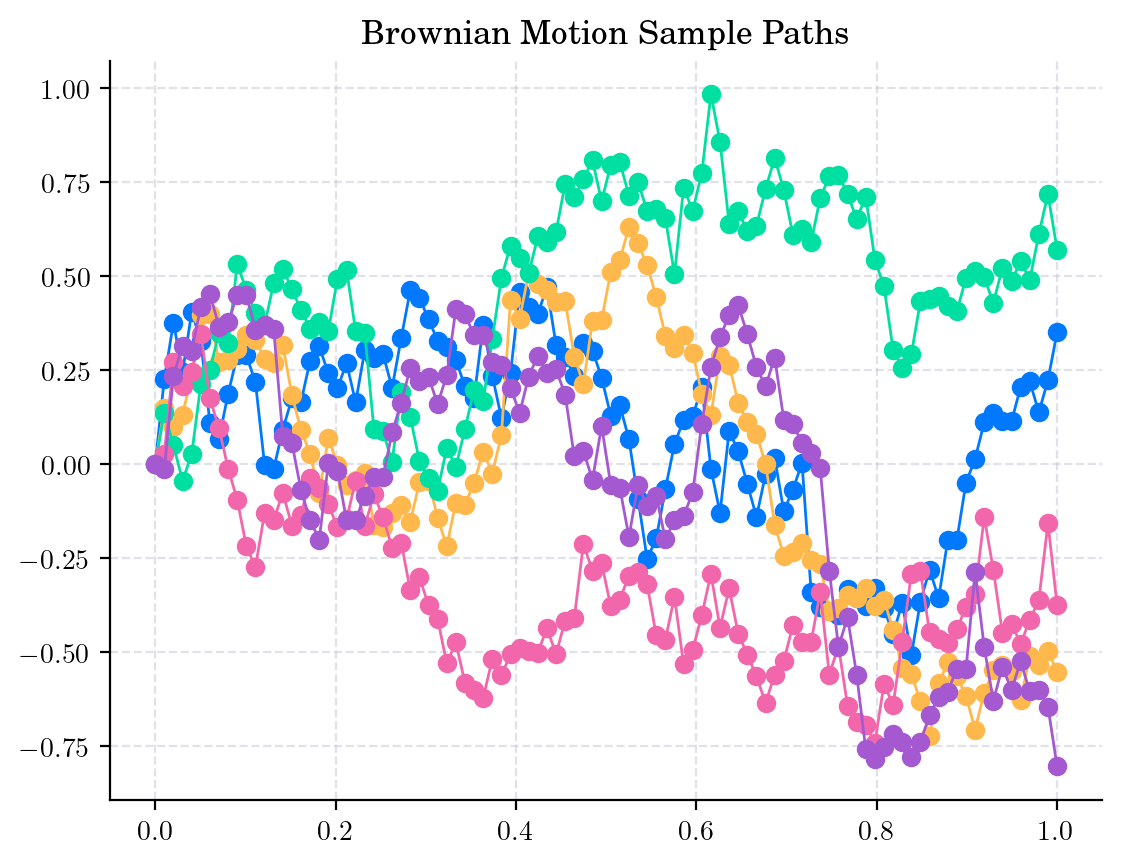

In [4]:
for sample in samples:
    plt.plot(times, sample, "o-", lw=1)
plt.title("Brownian Motion Sample Paths")
plt.show()

Putting these steps together we get the following snippet

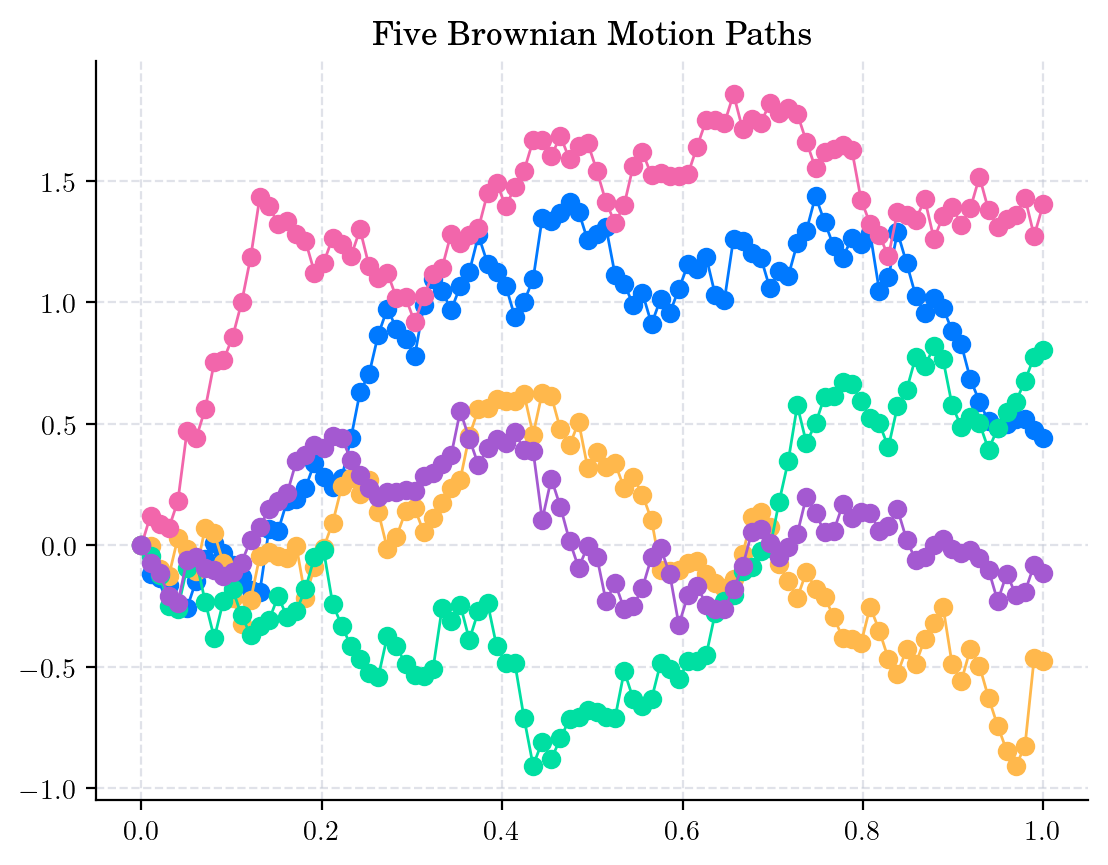

In [5]:
# Snippet to generate multiple sample paths from a Gaussian Process (Brownian Motion) and plot them
import numpy as np
from numpy.random import multivariate_normal
import matplotlib.pyplot as plt

T = 1.0  # End point of the interval to simulate [O,T]
n = 100  # Number of points in the partition
times = np.linspace(0, T, n)  # Partition


# Covariance Function (Kernel) for Brownian Motion
def covariance_function(t):
    return np.minimum.outer(t, t)

N = 5 # Number of sample paths to generate
samples = multivariate_normal(mean=np.zeros(n), cov=covariance_function(times), size=N) # Sample paths 

for sample in samples:
    plt.plot(times, sample, "o-", lw=1)
plt.title("Five Brownian Motion Paths")
plt.show()

Similarly, we can simulate paths from an Orstein-Uhlenbeck process and a Brownian Bridge.

In [6]:
# Covariance Function (Kernel) for Ornstein-Uhlenbeck Process
def ou_cov(t, theta=1.0, sigma=1.0):
    s, t_ = np.meshgrid(t, t)
    res = (sigma**2 / (2 * theta)) * np.exp(-(s + t_)) * (np.exp(2 * np.minimum(s, t_)) - 1) / 2
    return res

# Covariance Function (Kernel) for Brownian Bridge
def bridge_cov(t):
    return np.minimum.outer(t, t) - np.outer(t, t)

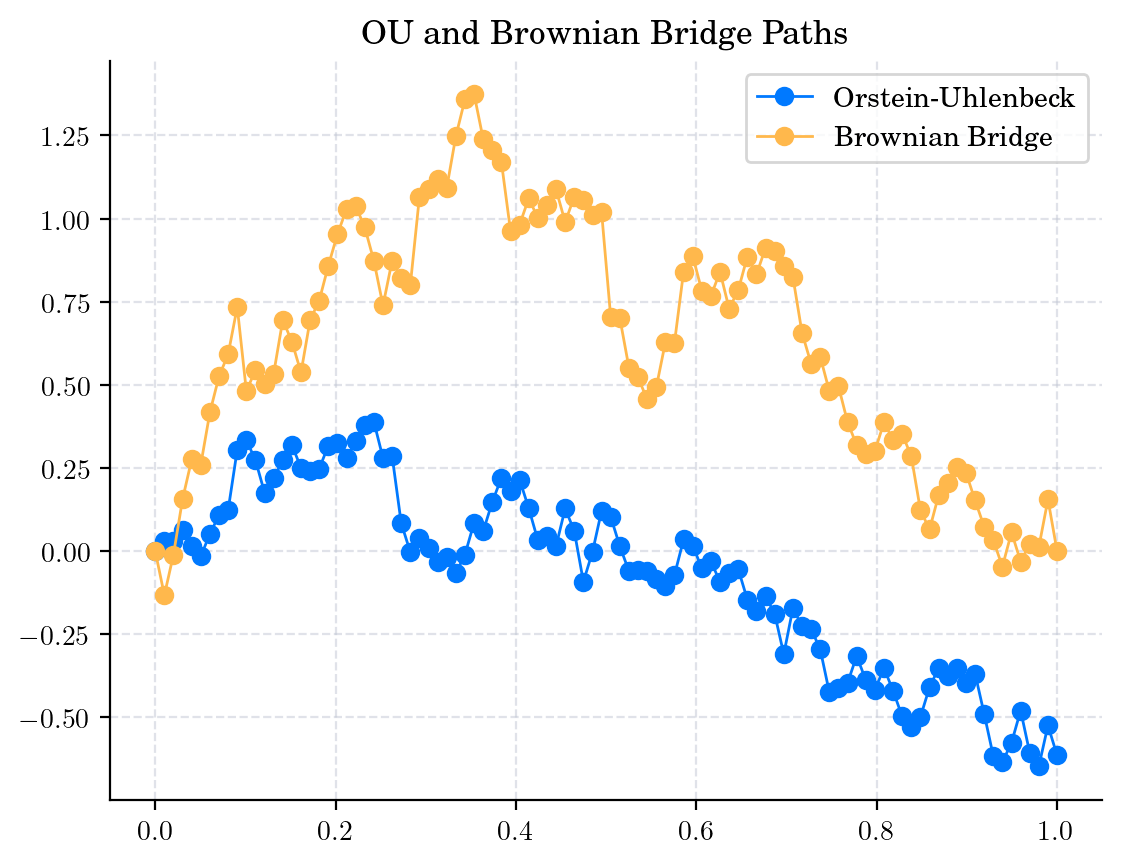

In [7]:
sample = multivariate_normal(mean=np.zeros(n), cov=ou_cov(times), size=1)[0]
plt.plot(times, sample, "o-", lw=1, label="Orstein-Uhlenbeck")
sample = multivariate_normal(mean=np.zeros(n), cov=bridge_cov(times), size=1)[0]
plt.plot(times, sample, "o-", lw=1, label="Brownian Bridge")
plt.title("OU and Brownian Bridge Paths")
plt.legend()
plt.show()

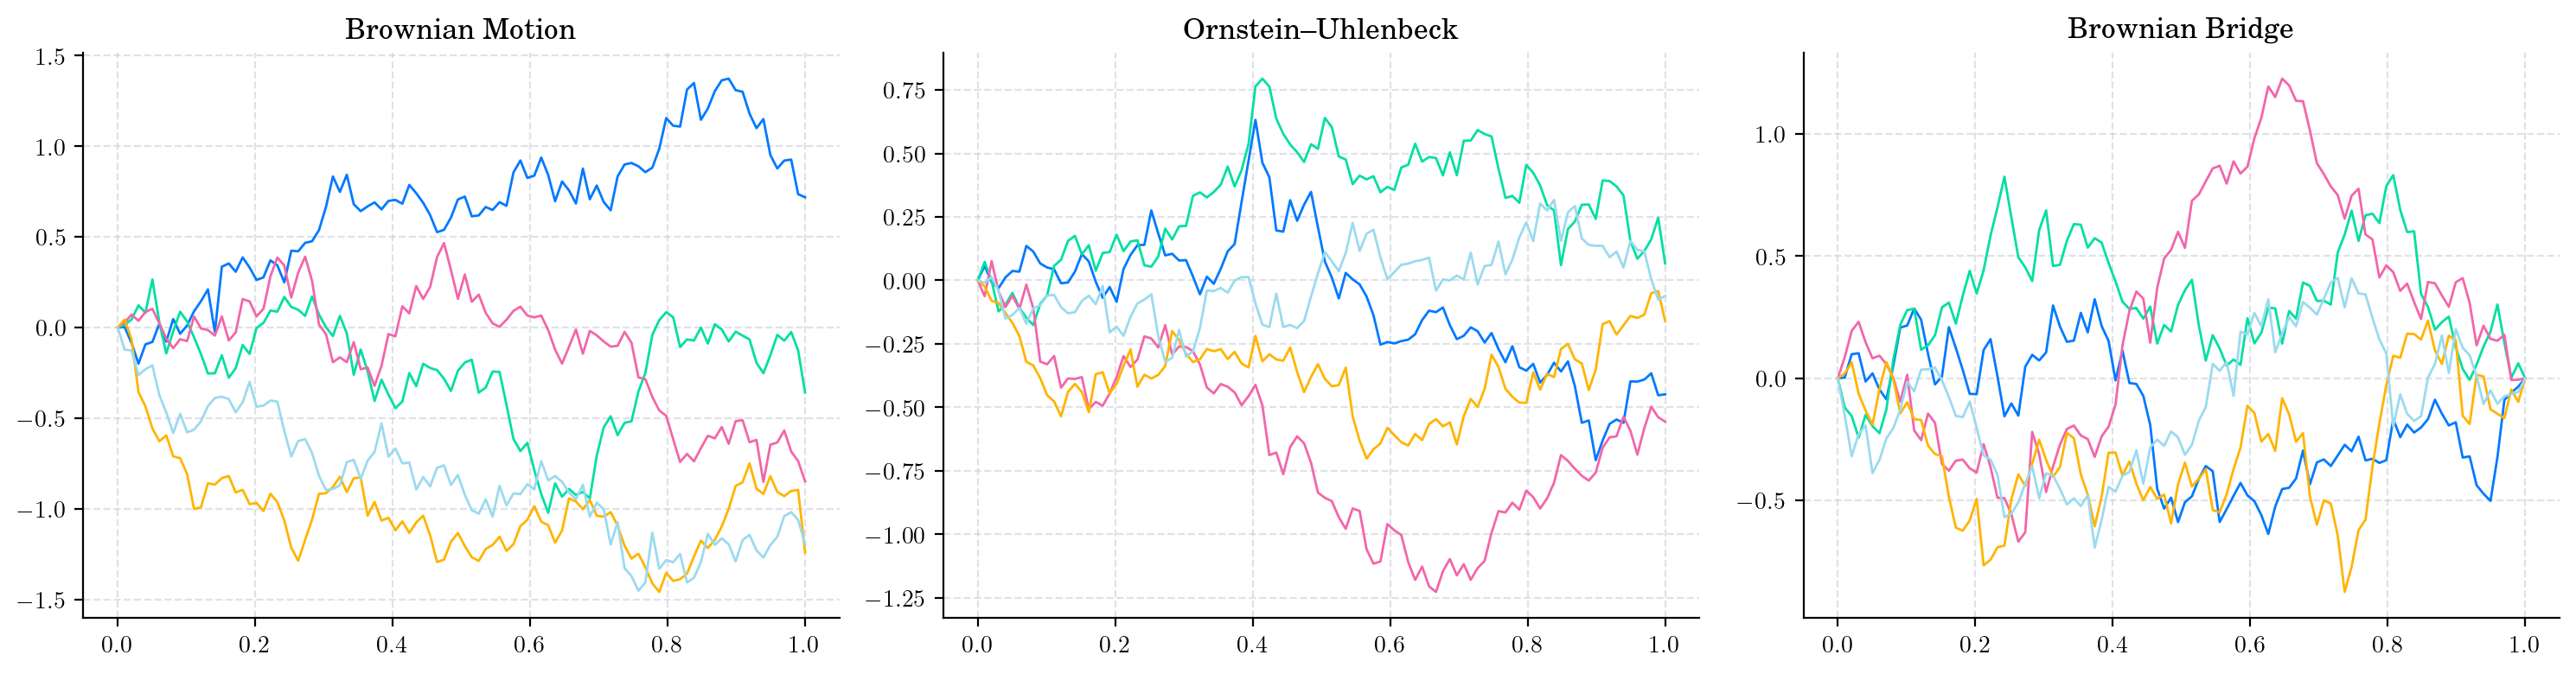

In [8]:
T = 1.0  # End point of the interval to simulate [O,T]
n = 100  # Number of points in the partition
times = np.linspace(0, T, n)  # Partition
N = 5  # Number of sample paths to simulate

kernels = [
    ("Brownian Motion", brownian_cov),
    ("Ornstein–Uhlenbeck", ou_cov),
    ("Brownian Bridge", bridge_cov),
]

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, cov_fn) in zip(axs, kernels):
    ax.set_prop_cycle(plt.cycler("color", ['#0079ff',  '#00dfa2', '#f266ab', '#ffb400', "#9bdaef"]))
    K = cov_fn(times)
    samples = multivariate_normal(np.zeros(len(times)), K, size=N)

    for s in samples:
        ax.plot(times, s)

    ax.set_title(title)

plt.tight_layout()
plt.show()

## Covariance Functions (Kernels)

In practice, the mean function is often taken to be zero (since any process can be centered), so the **covariance function (kernel)** fully characterizes the behaviour of the process. 

Let $ X = {X(t) : t \in \mathcal{T}} $ be a stochastic process. Its covariance function is given by 

$$
k(s,t) := \mathrm{Cov}(X(s), X(t)) = \mathbb{E}[X(s)X(t)].
$$

One can visualize this function in two ways:

-  as a matrix, where the $(i,j)$-th entry is $k(t_i, t_j)$ for a given partition $\{t_1, \cdots, t_n\}$ of the interval $[0,T]$ 
-  as a function of two variables, where the value of the function at $(s,t)$ is $k(s,t)$.

Let's visualize the covariance functions of the three processes we have simulated above.

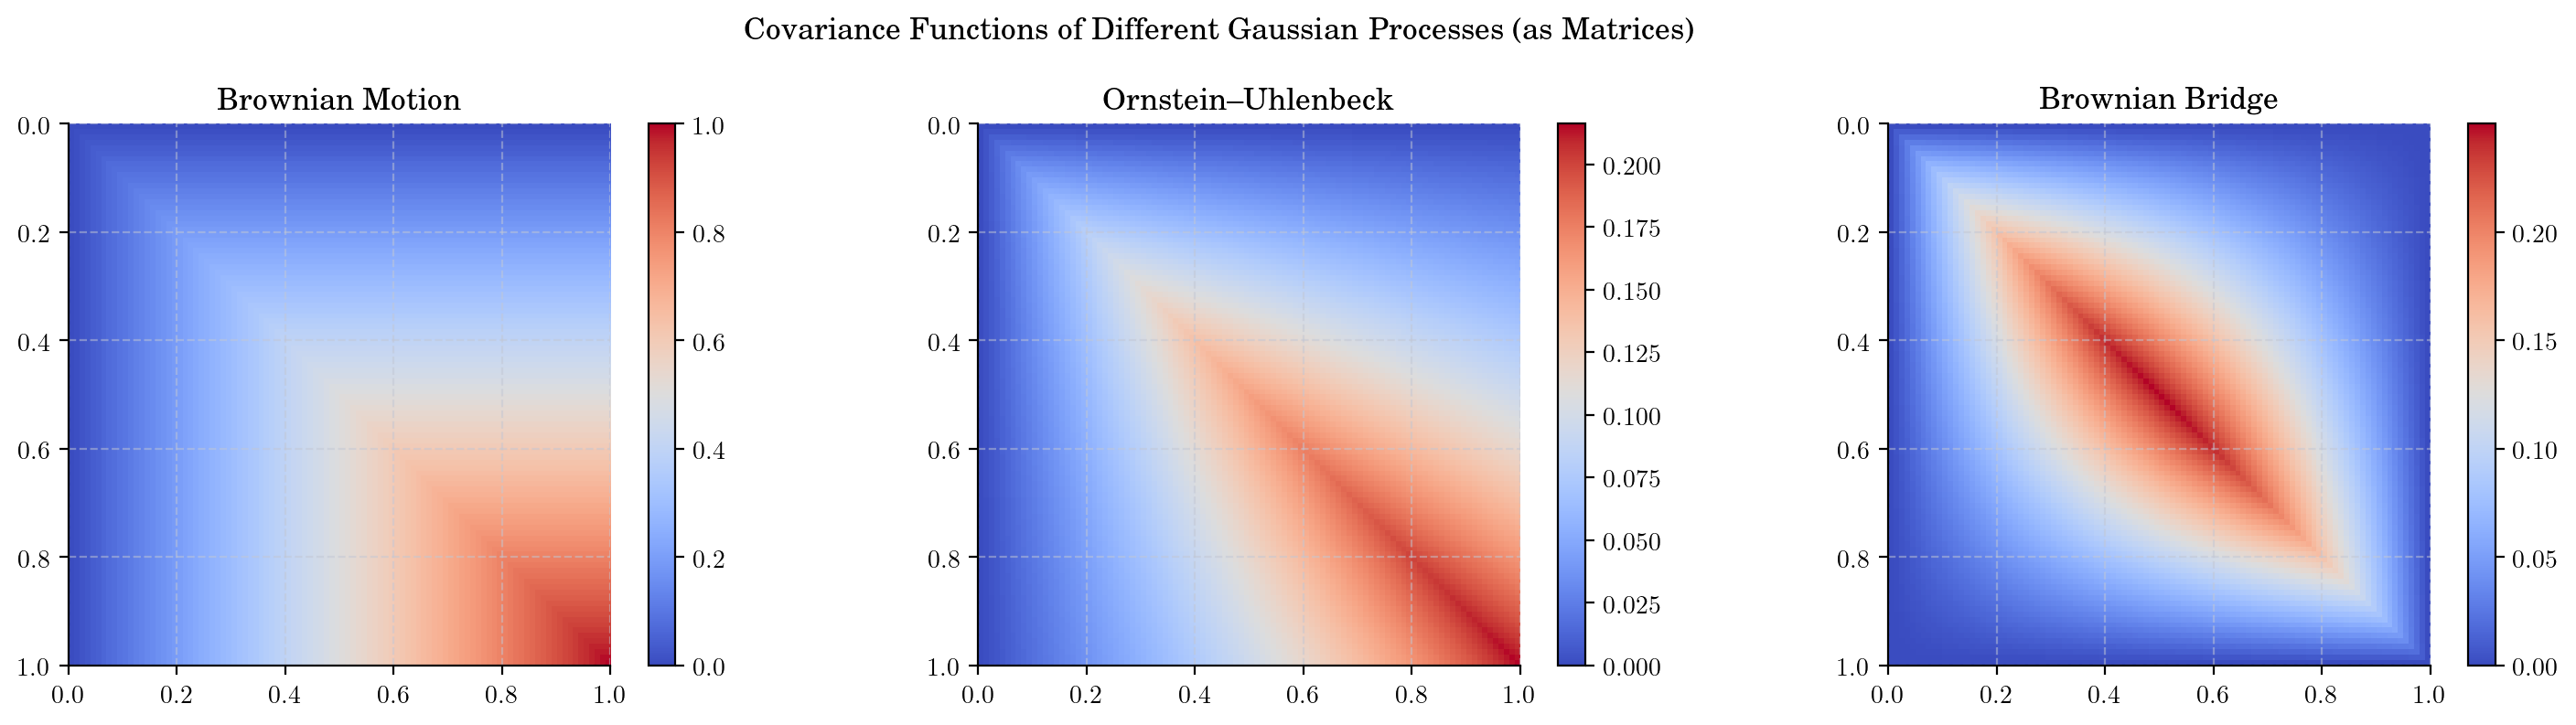

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, cov_fn) in zip(axs, kernels):
    K = cov_fn(times)
    im = ax.imshow(K, cmap="coolwarm", extent=[0, T, T, 0])
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Covariance Functions of Different Gaussian Processes (as Matrices)")
plt.tight_layout()
plt.show()

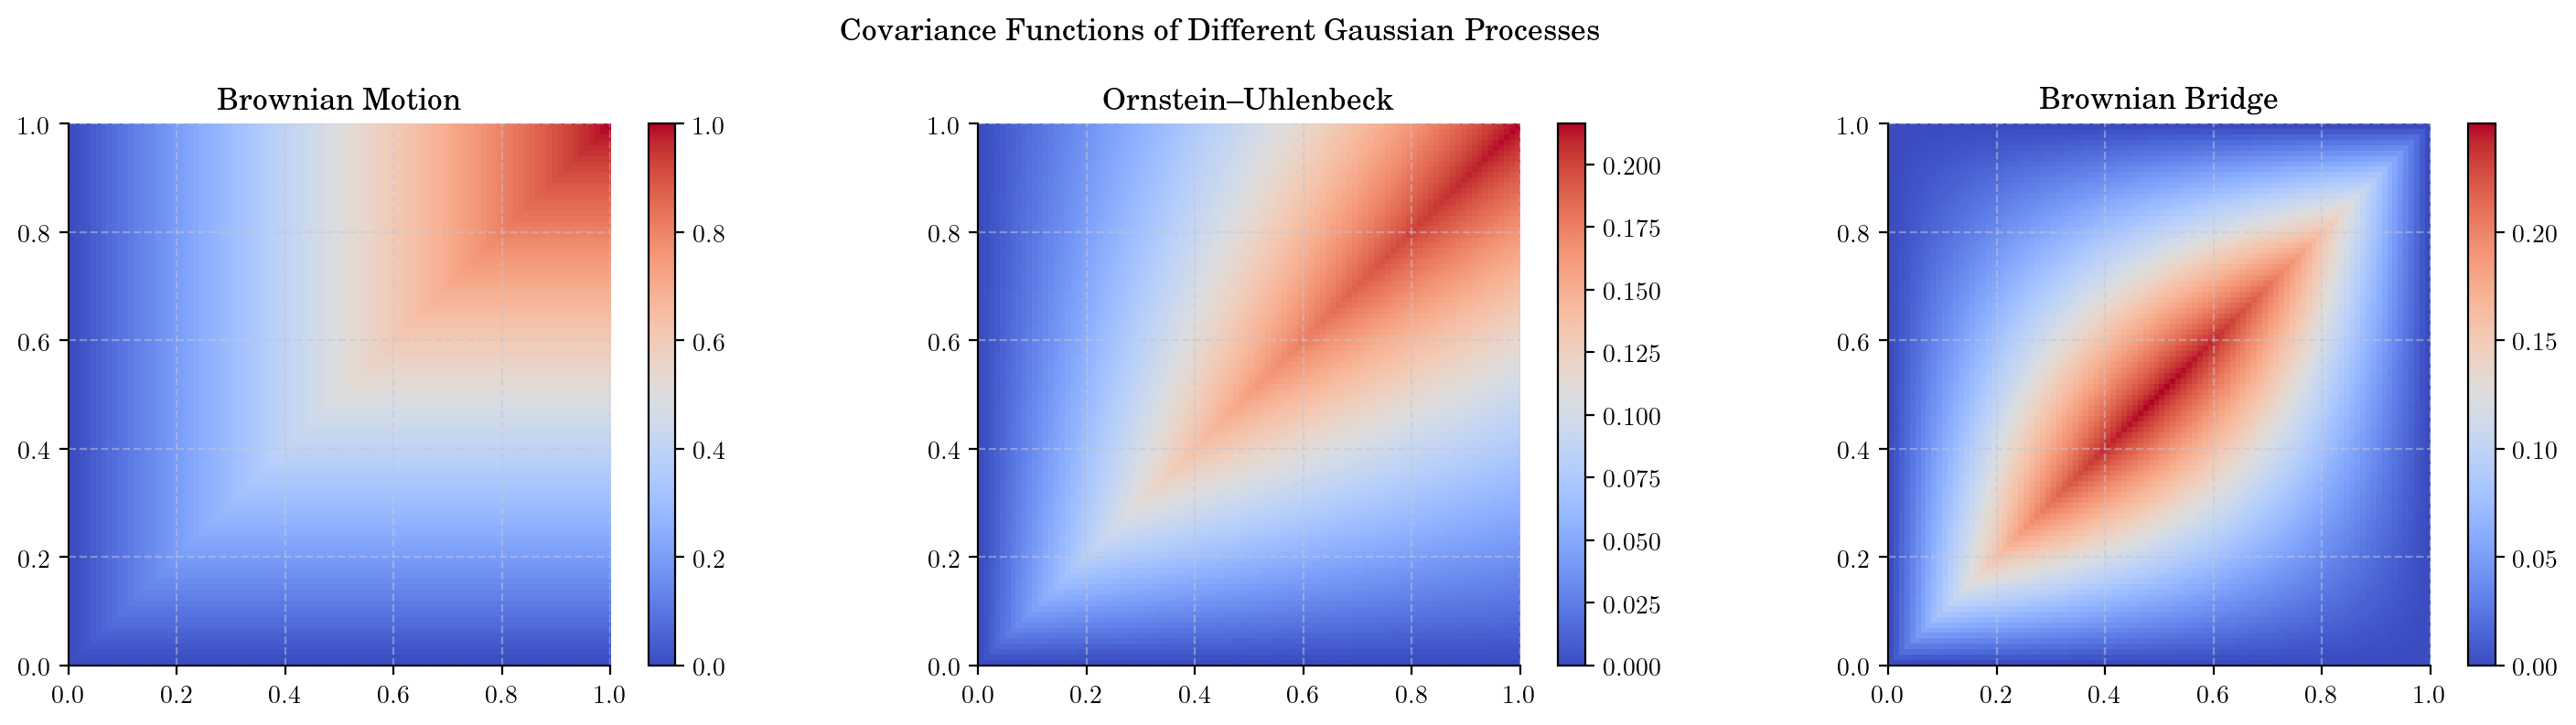

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, cov_fn) in zip(axs, kernels):
    K = cov_fn(times)
    im = ax.imshow(K, origin='lower', cmap="coolwarm", extent=[0, T, 0, T])
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Covariance Functions of Different Gaussian Processes")
plt.tight_layout()
plt.show()

Next, let's put together the paths and covariance functions in a single visualization.

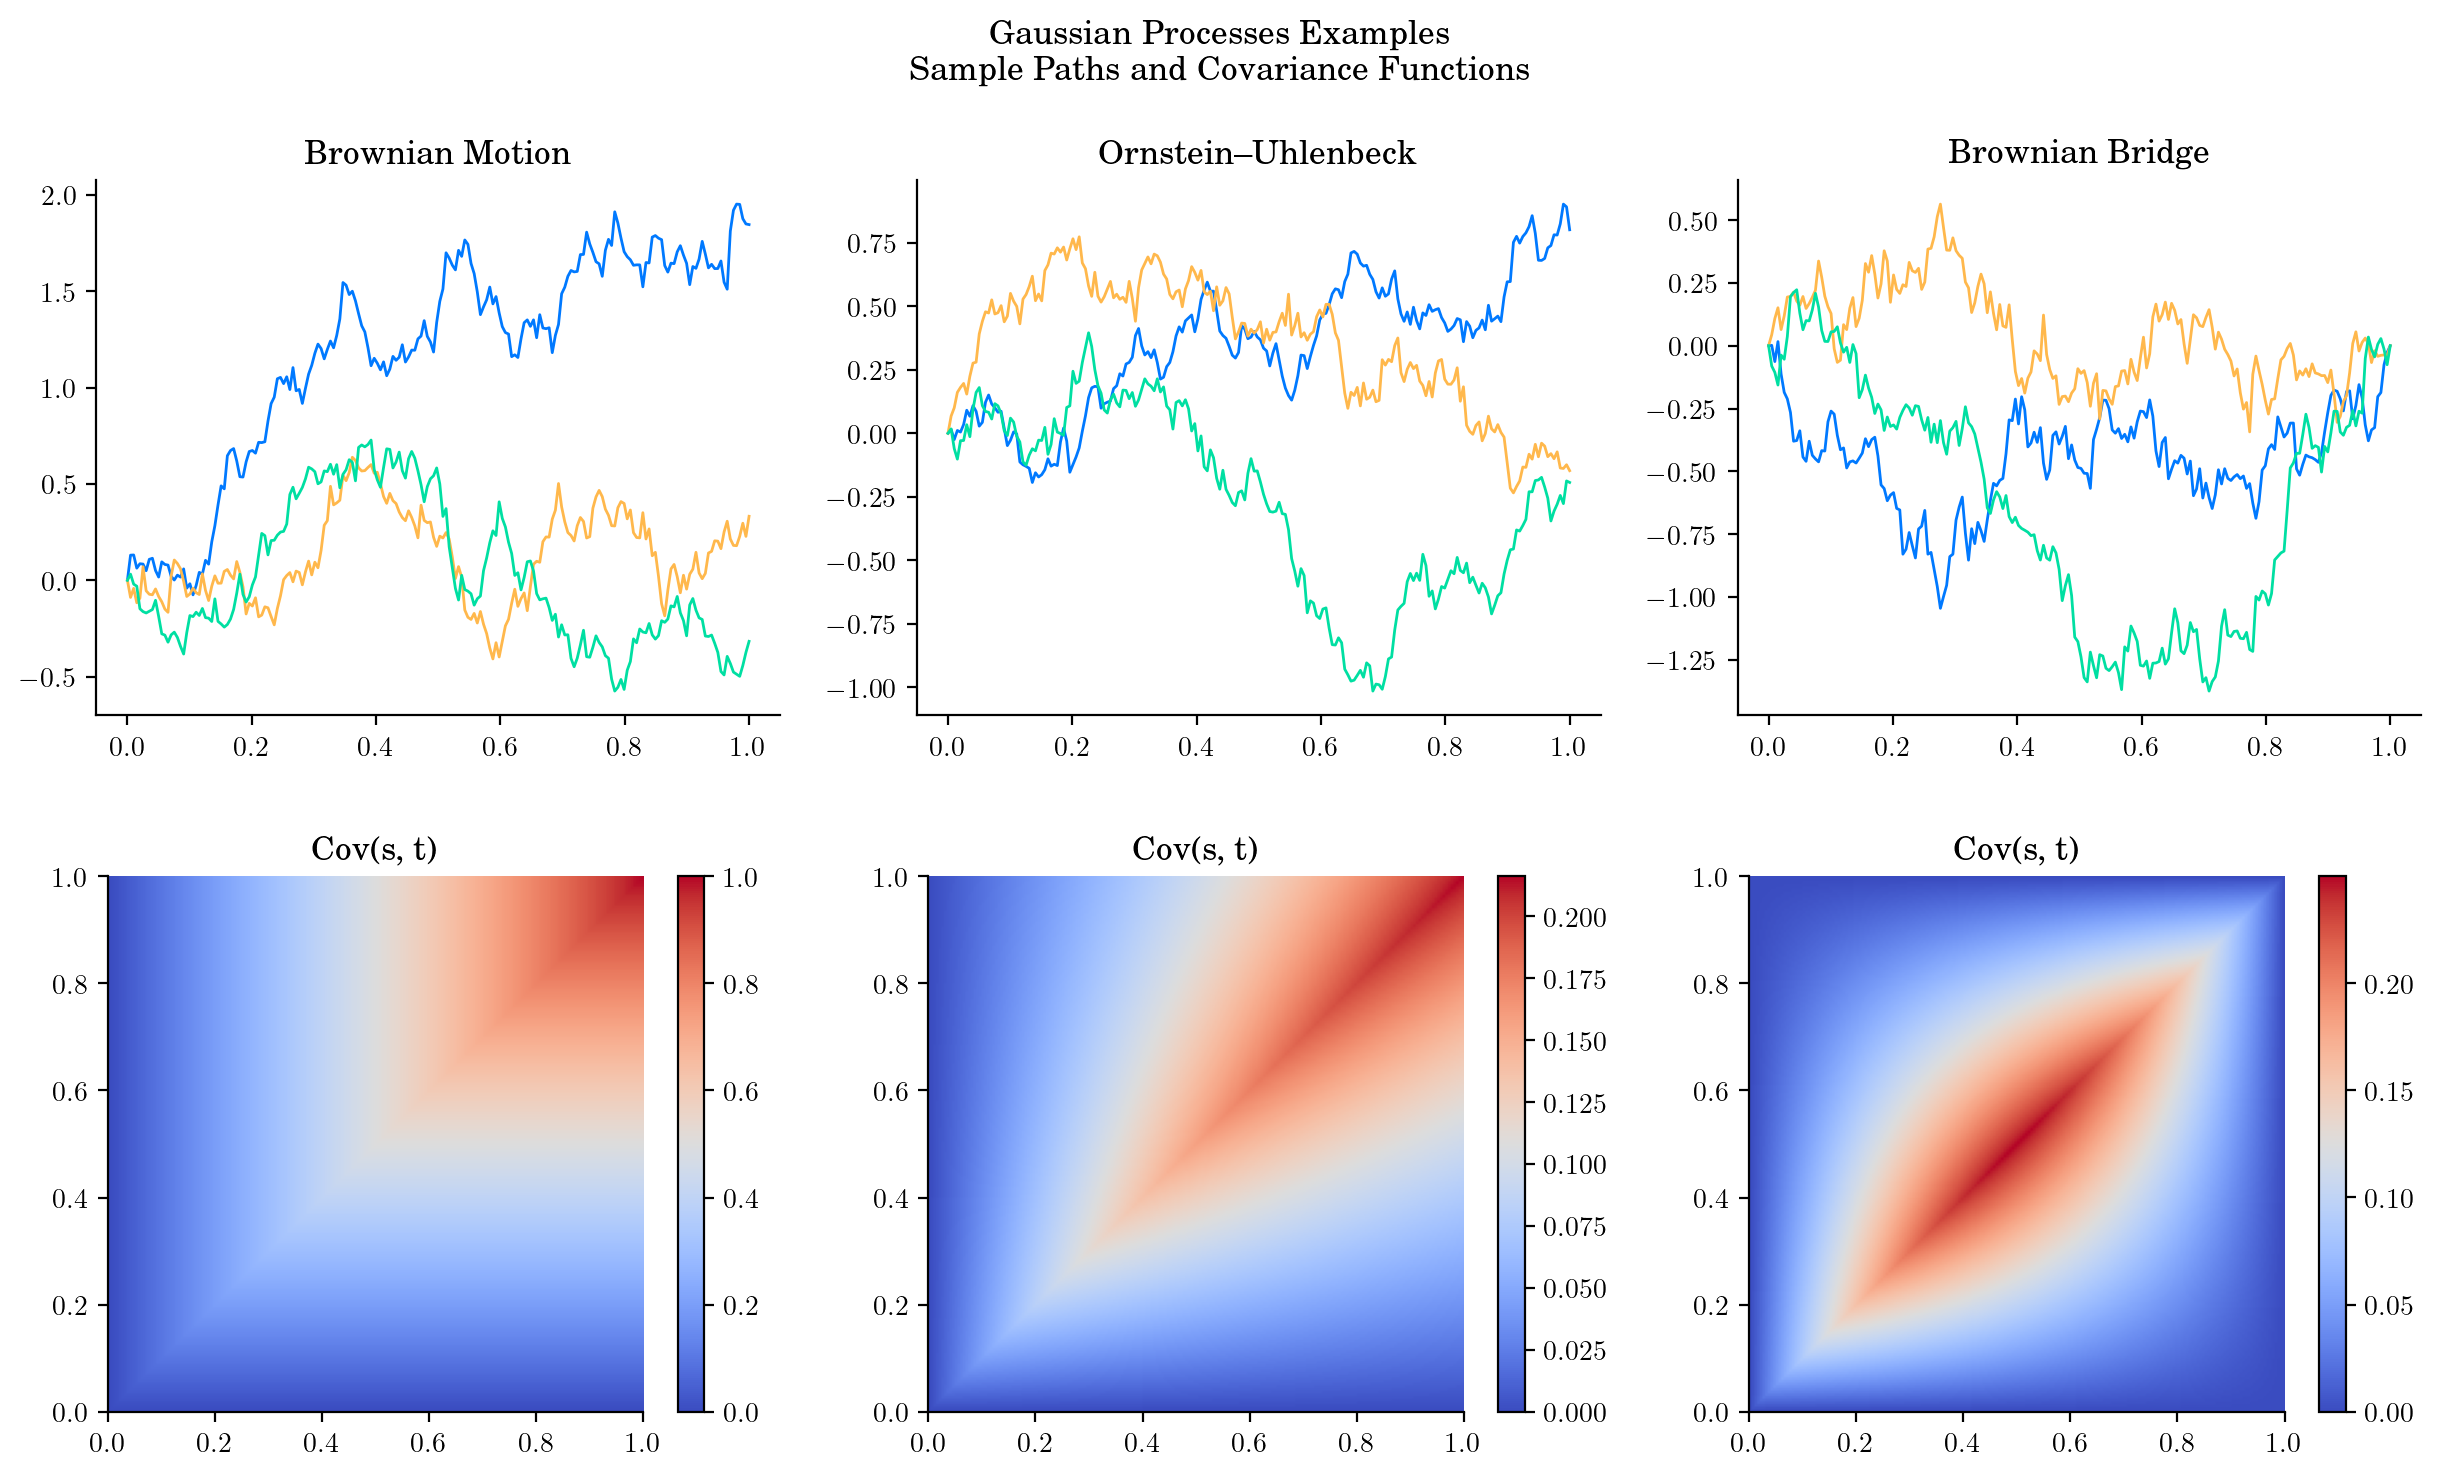

In [11]:
T = 1.0  # End point of the interval to simulate [O,T]
n = 200  # Number of points in the partition
times = np.linspace(0, T, n)  # Partition
N = 3  # Number of sample paths to simulate

fig, axs = plt.subplots(2, 3, figsize=(15, 8))

processes = [
    ("Brownian Motion", brownian_cov),
    ("Ornstein–Uhlenbeck", ou_cov),
    ("Brownian Bridge", bridge_cov),
]

for ax, (title, cov_fn) in zip(axs[0], processes):
    # ax.set_prop_cycle(plt.cycler(
    #     "color", ["#75dbfa",  "#069c58", '#f266ab', '#7f7f7f', '#bcbd22', '#17becf']))
    K = cov_fn(times)
    samples = multivariate_normal(np.zeros(len(times)), K, size=N)

    for s in samples:
        ax.plot(times, s)
    ax.set_title(title)
    ax.grid(False)

for ax, (title, cov_fn) in zip(axs[1], processes):
    K = cov_fn(times)
    im = ax.imshow(K, extent=(0, T, 0, T), origin="lower", cmap="coolwarm")
    plt.colorbar(im, ax=ax) 
    ax.set_title("Cov(s, t)")
    ax.grid(False)

plt.suptitle("Gaussian Processes Examples\n Sample Paths and Covariance Functions")
plt.subplots_adjust(hspace=0.3)
# plt.tight_layout(rect=[0, 0.05, 1, 0.975])
plt.show()

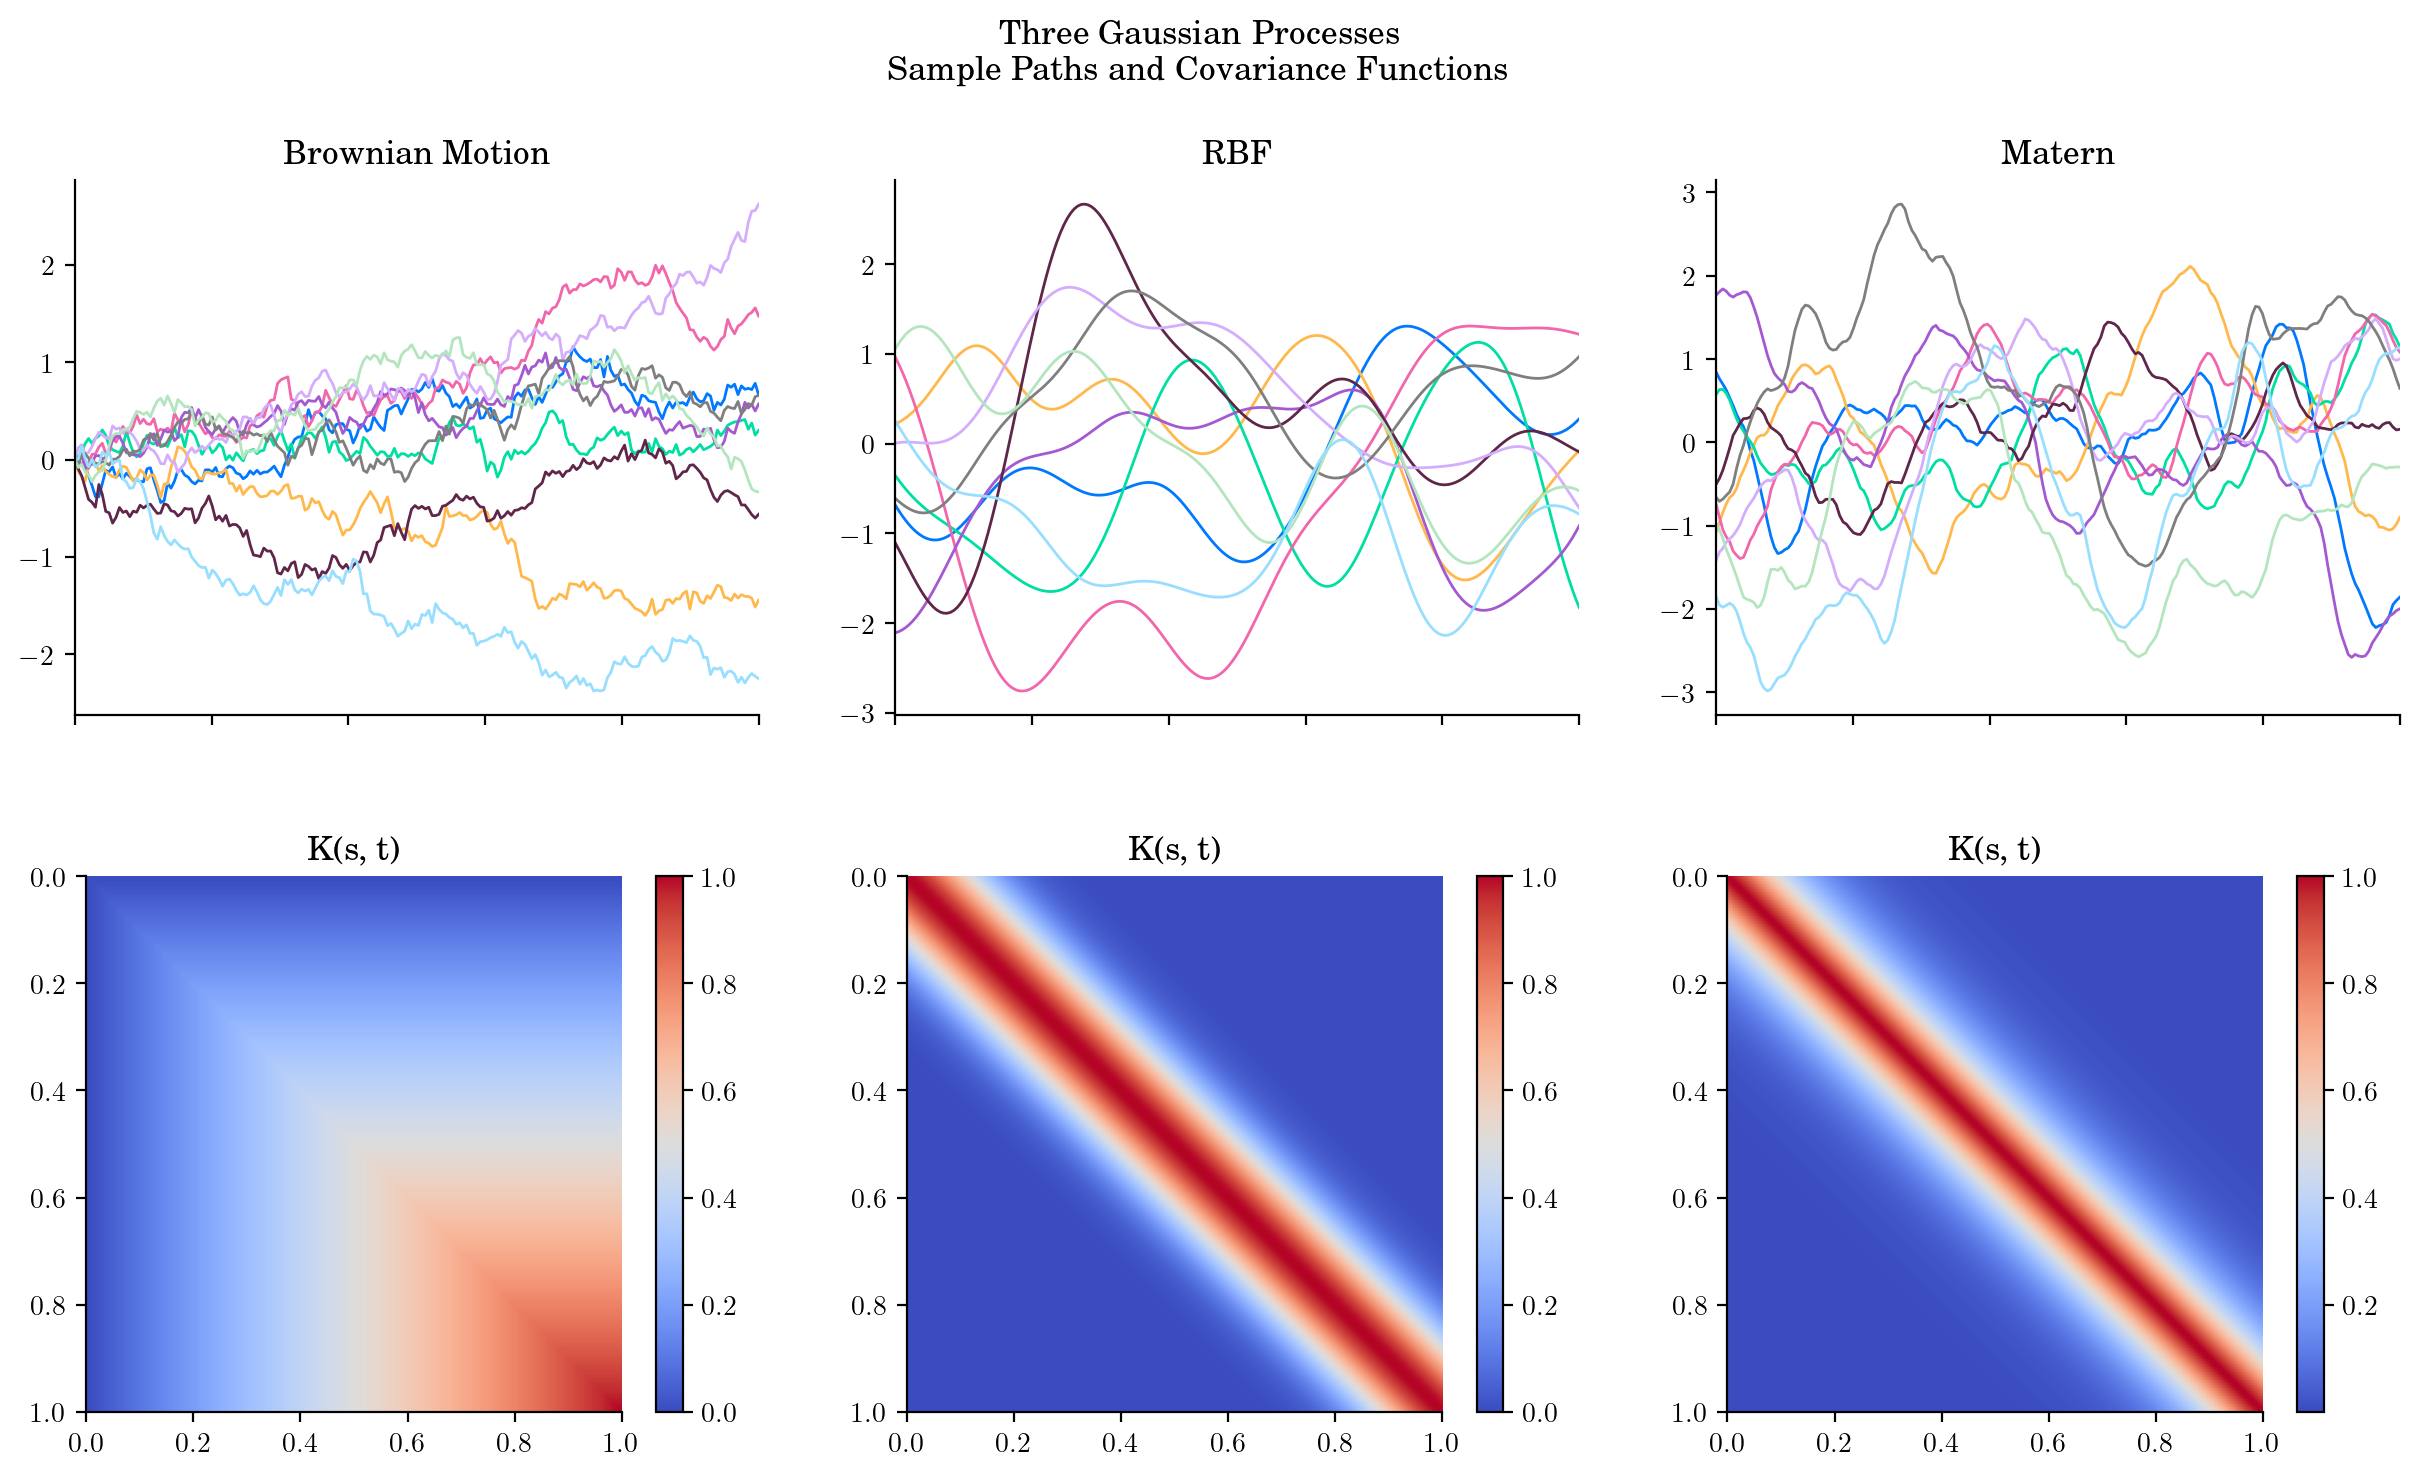

In [12]:
def square_exponential_cov(t, length_scale=0.1, sigma=1.0):
    s, t_ = np.meshgrid(t, t)
    return sigma**2 * np.exp(-0.5 * ((s - t_) / length_scale) ** 2)


def matern_cov(times, length_scale=0.1, sigma=1.0, nu=1.5):
    from scipy.spatial.distance import pdist, squareform

    pairwise_dists = squareform(pdist(times[:, None], metric="euclidean"))
    if nu == 0.5:
        return sigma**2 * np.exp(-pairwise_dists / length_scale)
    elif nu == 1.5:
        sqrt3 = np.sqrt(3)
        return (
            sigma**2
            * (1 + sqrt3 * pairwise_dists / length_scale)
            * np.exp(-sqrt3 * pairwise_dists / length_scale)
        )
    elif nu == 2.5:
        sqrt5 = np.sqrt(5)
        return (
            sigma**2
            * (
                1
                + sqrt5 * pairwise_dists / length_scale
                + 5 * pairwise_dists**2 / (3 * length_scale**2)
            )
            * np.exp(-sqrt5 * pairwise_dists / length_scale)
        )
    else:
        raise ValueError("Unsupported nu value. Use 0.5, 1.5, or 2.5.")


T = 1.0  # End point of the interval to simulate [O,T]
n = 200  # Number of points in the partition
times = np.linspace(0, T, n)  # Partition
N = 3  # Number of sample paths to simulate


kernels = [
    ("Brownian Motion", brownian_cov),
    ("RBF", square_exponential_cov),
    ("Matern", matern_cov),
]

fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

for ax, (title, cov_fn) in zip(axs[0], kernels):
    # ax.set_prop_cycle(plt.cycler(
    #     "color", ["#75dbfa",  "#069c58", '#f266ab', '#7f7f7f', '#bcbd22', '#17becf']))
    K = cov_fn(times)
    samples = multivariate_normal(np.zeros(len(times)), K, size=10)

    for s in samples:
        ax.plot(times, s)
    ax.set_title(title)
    ax.grid(False)

for ax, (title, cov_fn) in zip(axs[1], kernels):
    K = cov_fn(times)
    im = ax.imshow(K, extent=(0, T, T, 0), origin="upper", cmap="coolwarm")
    plt.colorbar(im, ax=ax)
    ax.set_title("K(s, t)")
    ax.grid(False)

plt.suptitle(
    "Three Gaussian Processes\n Sample Paths and Covariance Functions")
plt.subplots_adjust(hspace=0.3)
plt.show()

## Common Covariance Functions and their corresponding Gaussian Processes

Hereafter, let $$ d = \|x - x'\| $$ denote the distance between inputs.


### 1. Constant Kernel

$$
k(x,x') = C
$$

**Intuition**

- All points are perfectly correlated  
- No dependence on distance  

**Typical path behaviour**

- Functions are constant but random in level

**Interpretation**

> The function is flat but uncertain in magnitude.

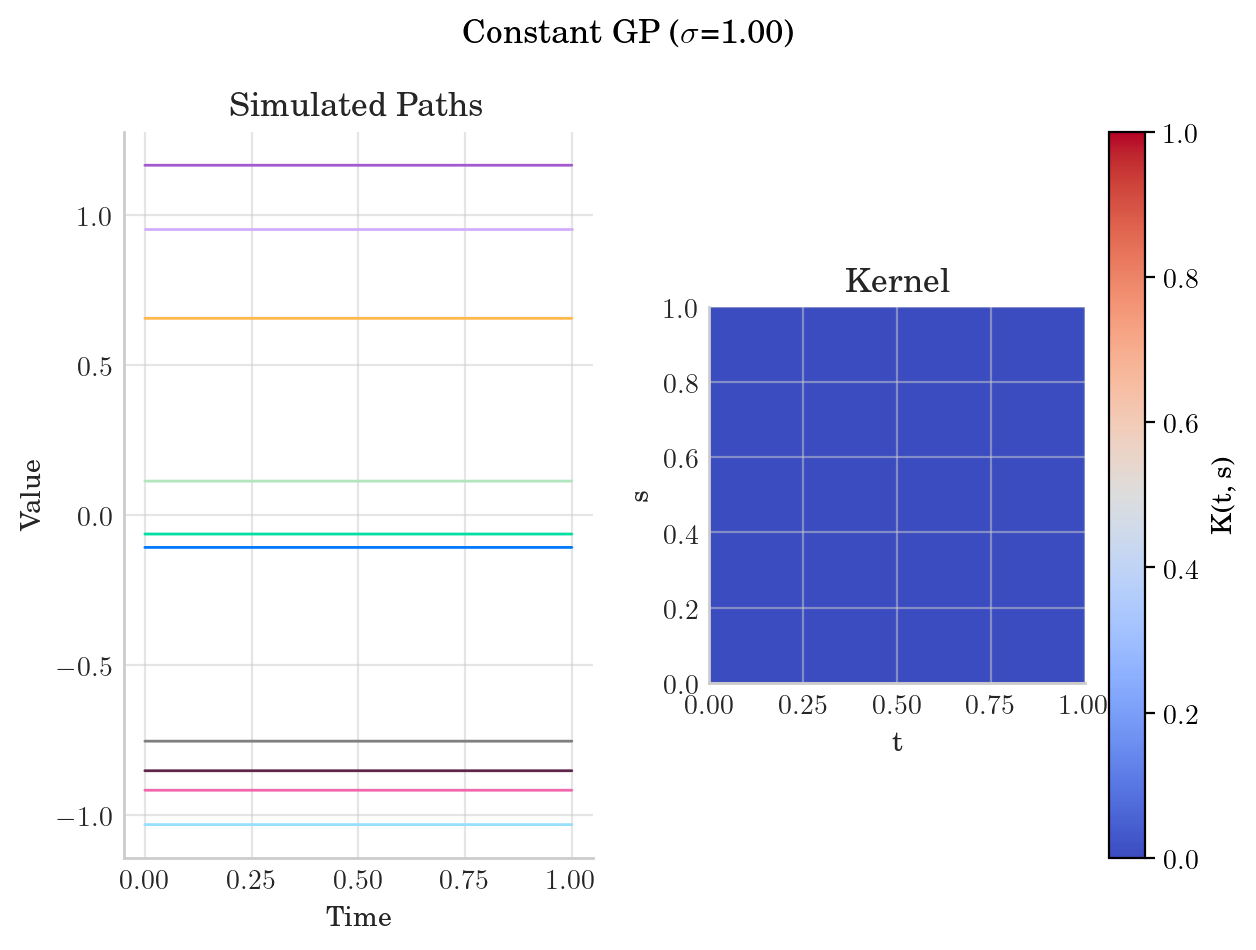

In [13]:
from aleatory.processes import GPConstant
p = GPConstant(sigma=1.0)
fig = p.plot_paths_and_kernel(n=100, N=10)

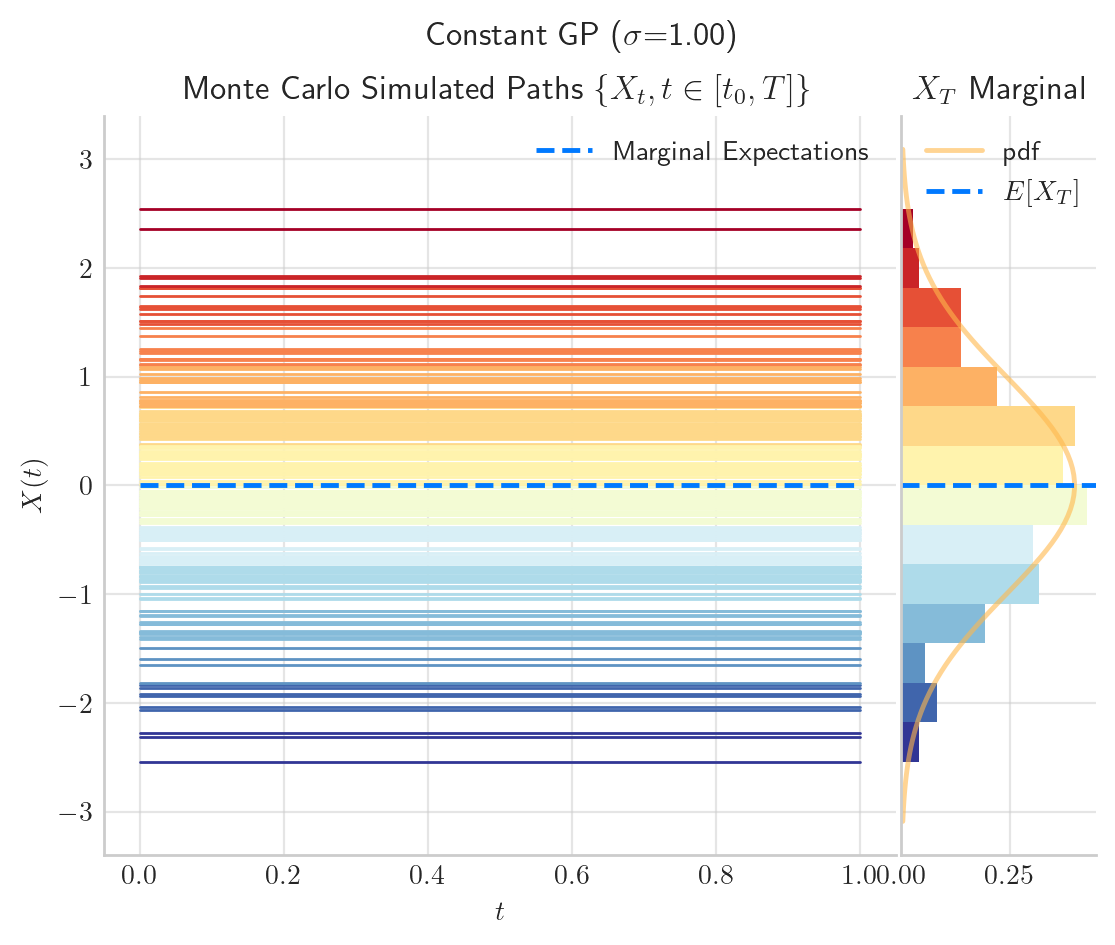

In [14]:
fig = p.draw(n=100, N=200)

### 2. Linear Kernel

$$
k(x,x') = x^\top x'
$$

**Intuition**

- Correlation increases with alignment of inputs. Note that the kernel is not stationary, as it depends on the absolute values of the inputs, not just their difference.

**Typical paths behaviour**

- Linear functions 

**Interpretation**

> Equivalent to Bayesian linear regression because the kernel is the inner product of the inputs.



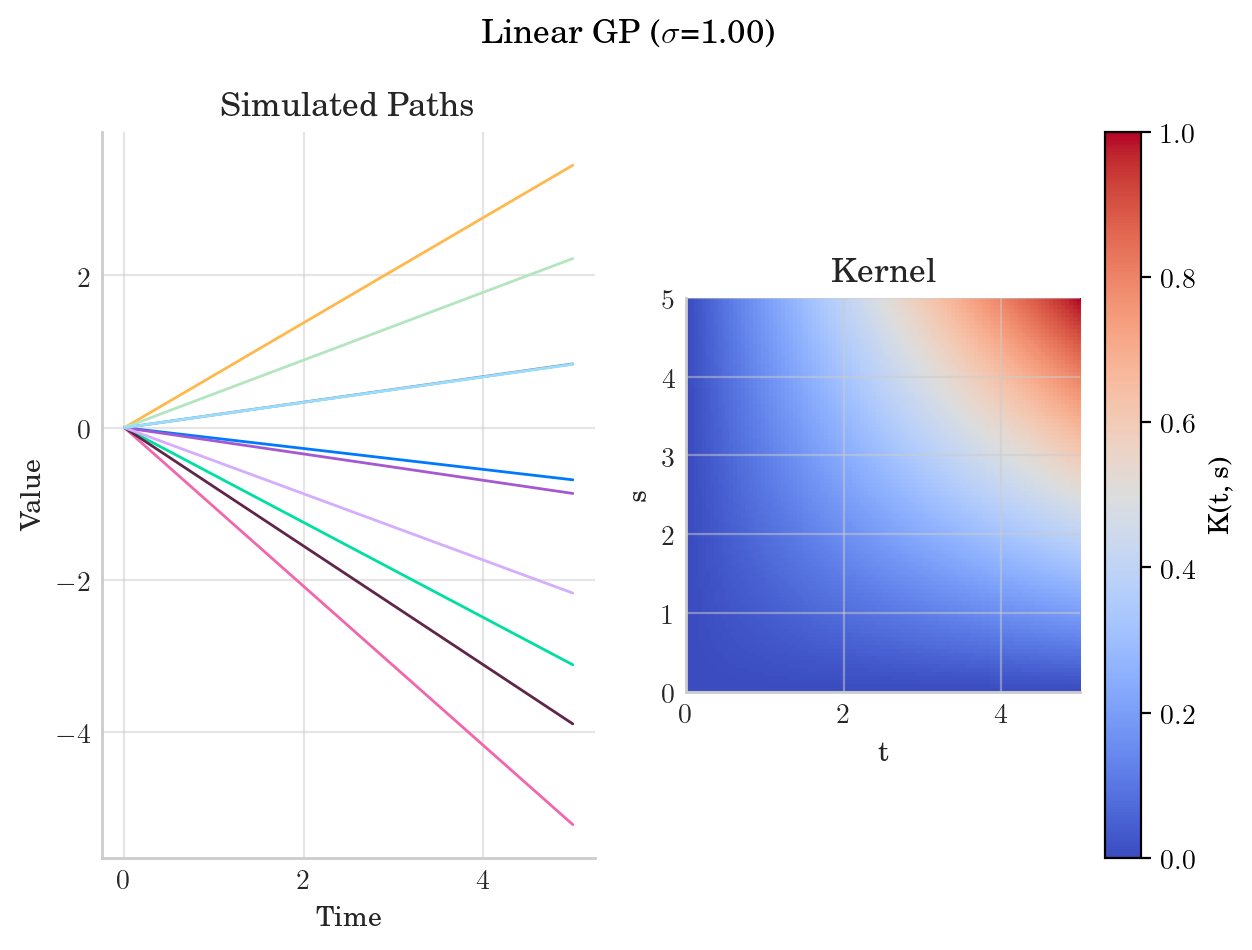

In [15]:
from aleatory.processes import GPLinear

p = GPLinear(sigma=1.0, T=5.0)
fig = p.plot_paths_and_kernel(n=100, N=10)

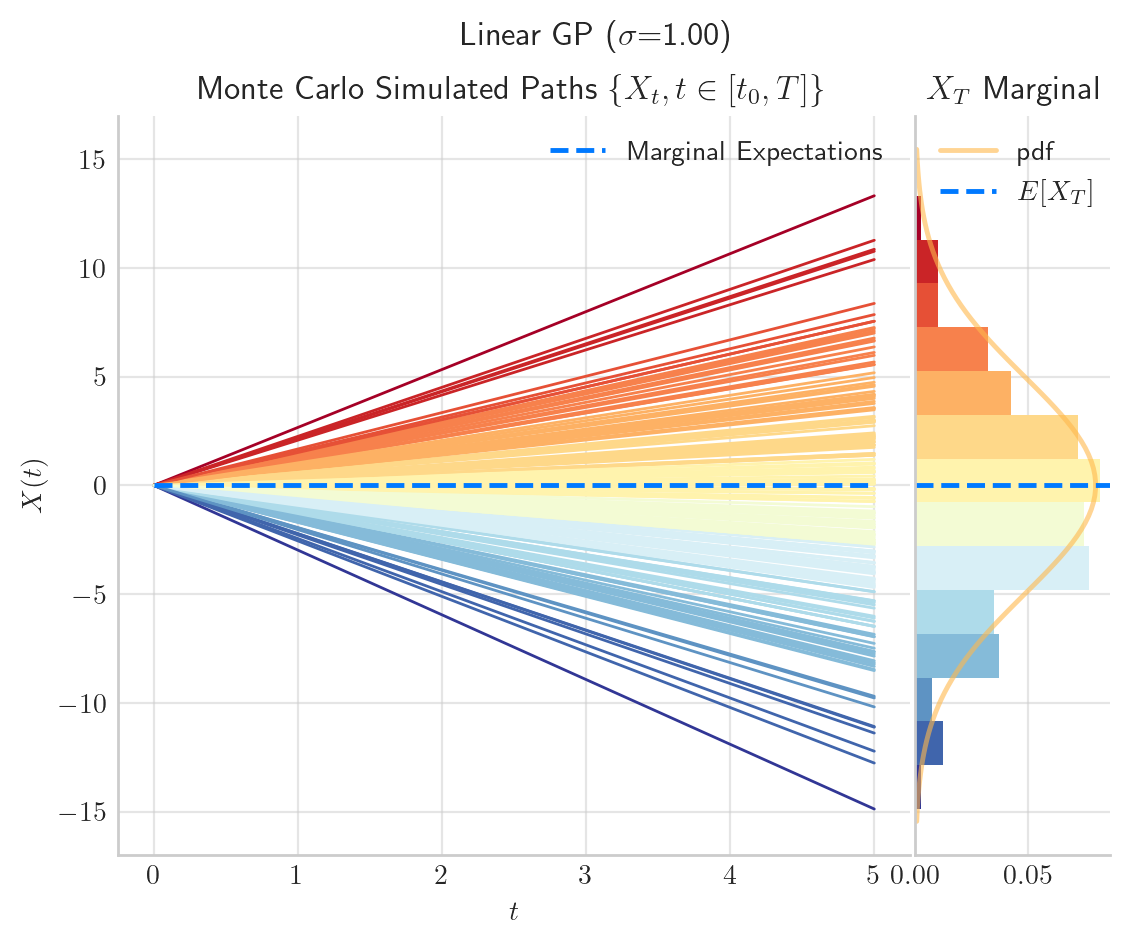

In [16]:
fig = p.draw(n=100, N=200)


### 3. White Noise Kernel

$$
K(x,x') = \sigma^2 \delta_{x,x'}
$$

**Intuition**

- No correlation between different inputs

**Typical paths behaviour**

- Unstructured noise, non-smooth functions

**Interpretation**

> Pure randomness with no smoothness.

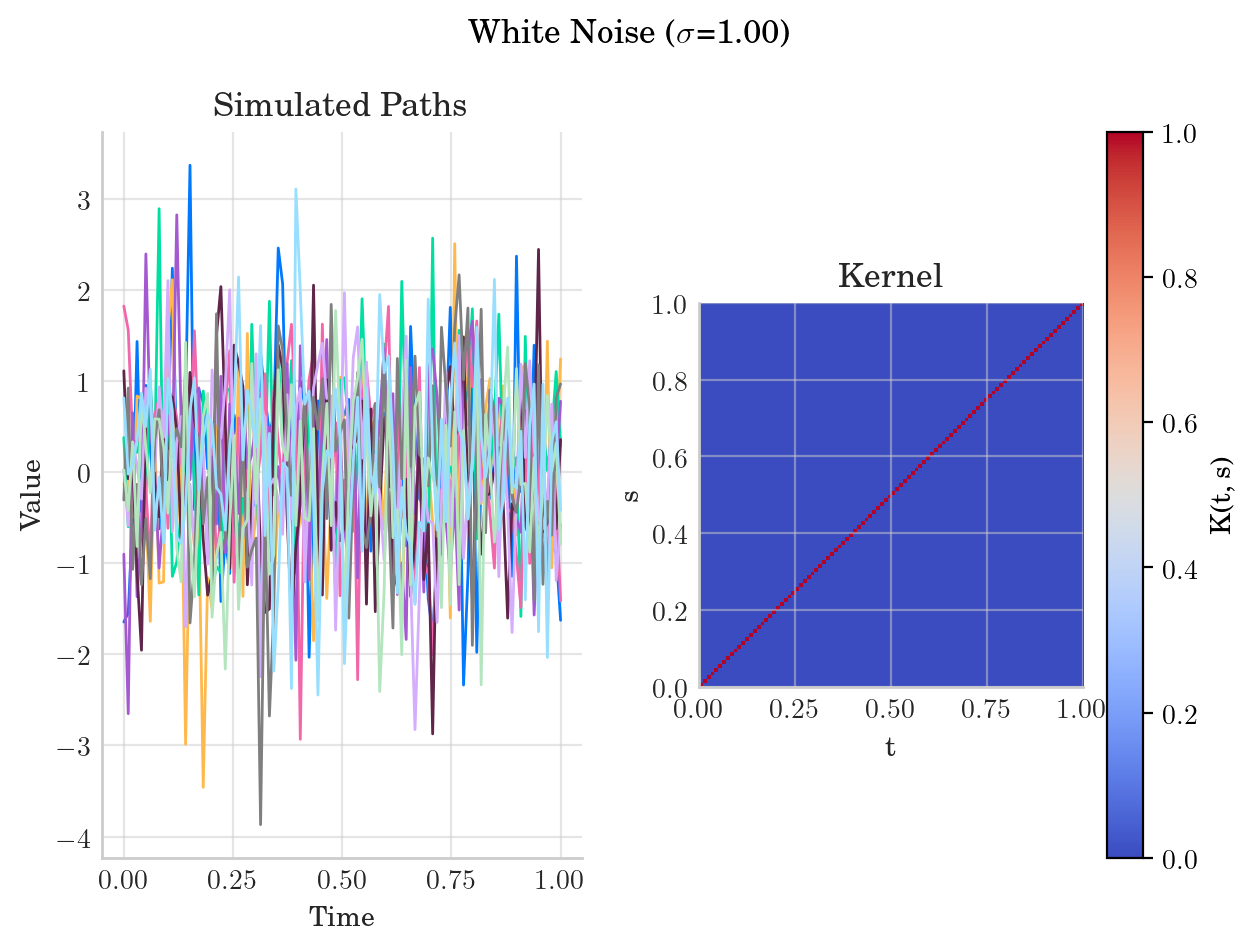

In [17]:
from aleatory.processes import WhiteNoise
p = WhiteNoise(sigma=1.0)
fig = p.plot_paths_and_kernel(n=100, N=10)

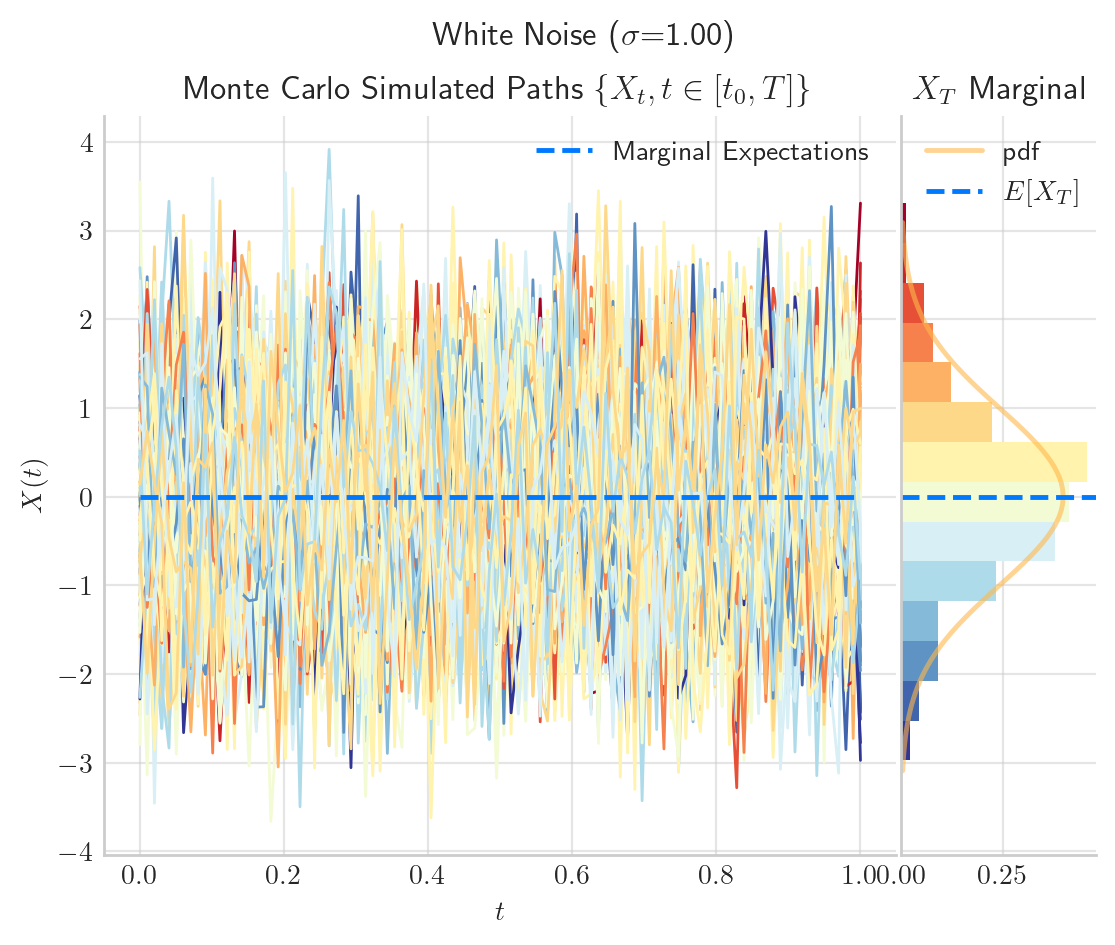

In [18]:
fig = p.draw(n=100, N=200)

### 4. Squared Exponential (RBF) Kernel

$$
K(x,x') = \exp\left(-\frac{d^2}{2\ell^2}\right)
$$

**Intuition**

- Nearby points are strongly correlated  
- Correlation decays smoothly with distance  

**Typical paths behaviour**

- Very smooth functions  

**Interpretation**

> Assumes the underlying function is extremely smooth.

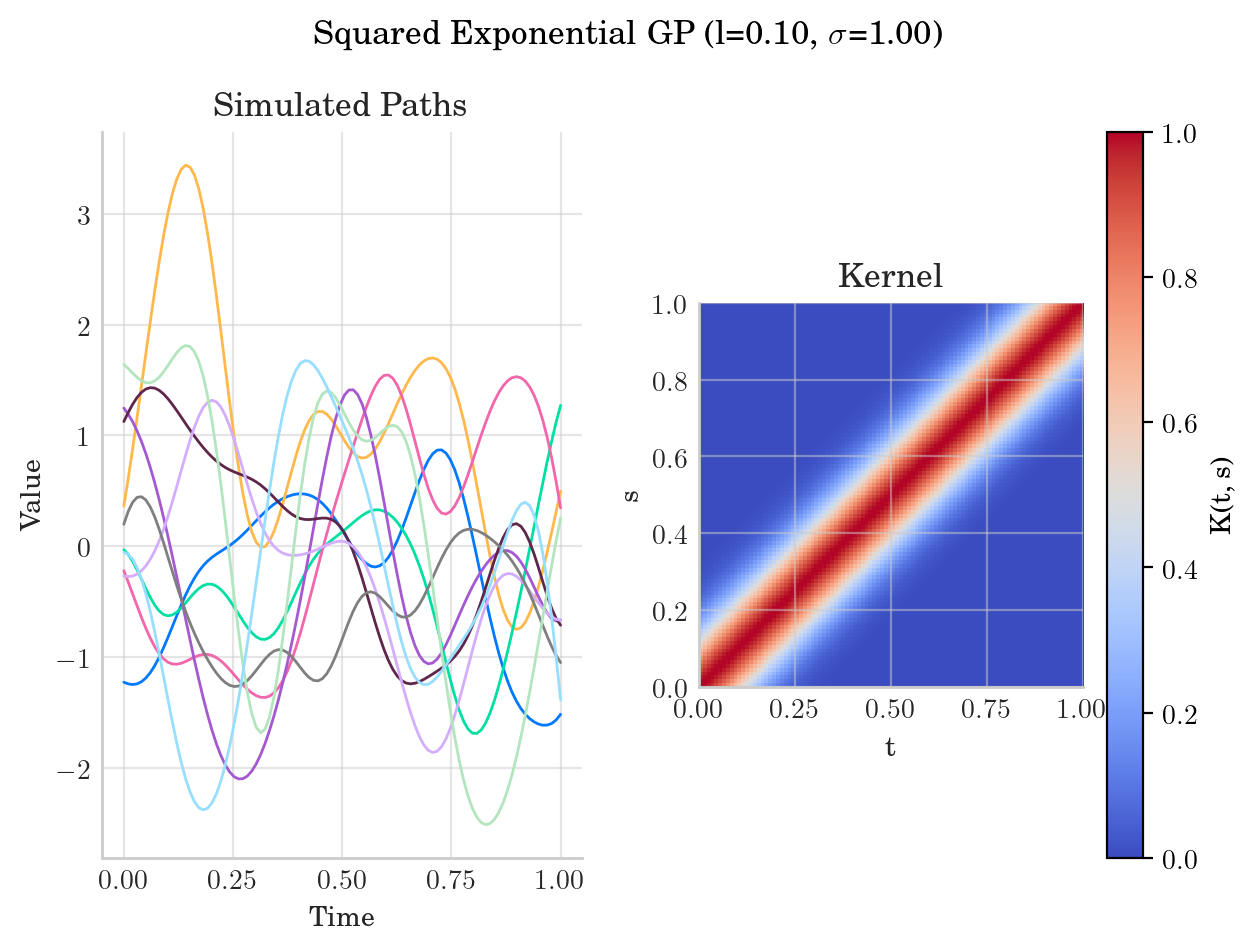

In [19]:
from aleatory.processes import GPSquaredExponential
p = GPSquaredExponential(sigma=1.0, length_scale=0.1)
fig = p.plot_paths_and_kernel(n=100, N=10)

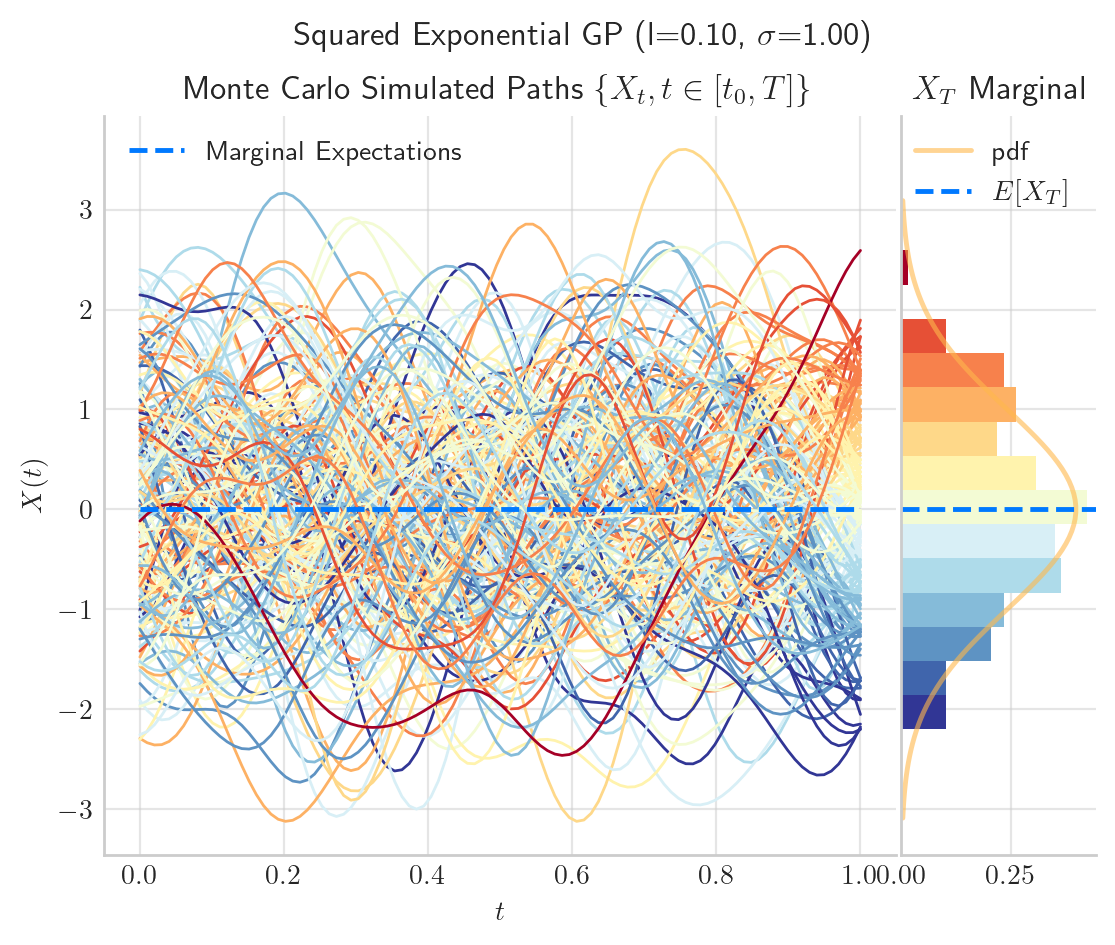

In [20]:
fig = p.draw(n=100, N=200)

### 5. Ornstein–Uhlenbeck Kernel

$$K(x, x') = \frac{\sigma^2 }{ 2\theta}e^{-\theta (x+x')} (e^{2\theta \min\{x,x'\}}-1),$$

**Intuition**

- Correlation decays exponentially with distance

**Typical paths behaviour**

- Continuous but rough paths showing mean-reverting behaviour  

**Interpretation**

> Captures mean-reverting behaviour.

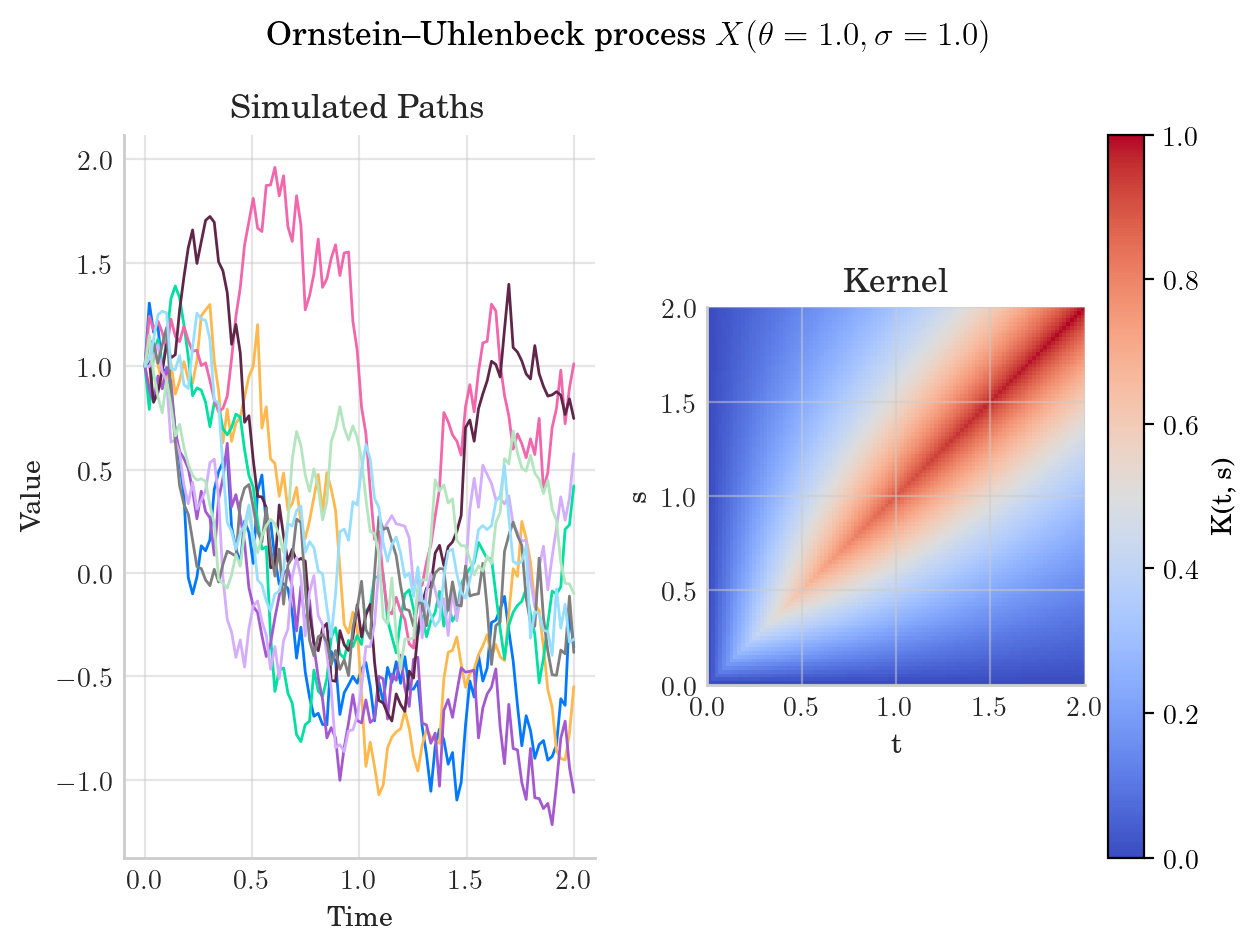

In [21]:
from aleatory.processes import OUProcess
p = OUProcess(sigma=1.0, theta=1.0, T=2.0)
fig = p.plot_paths_and_kernel(n=100, N=10)

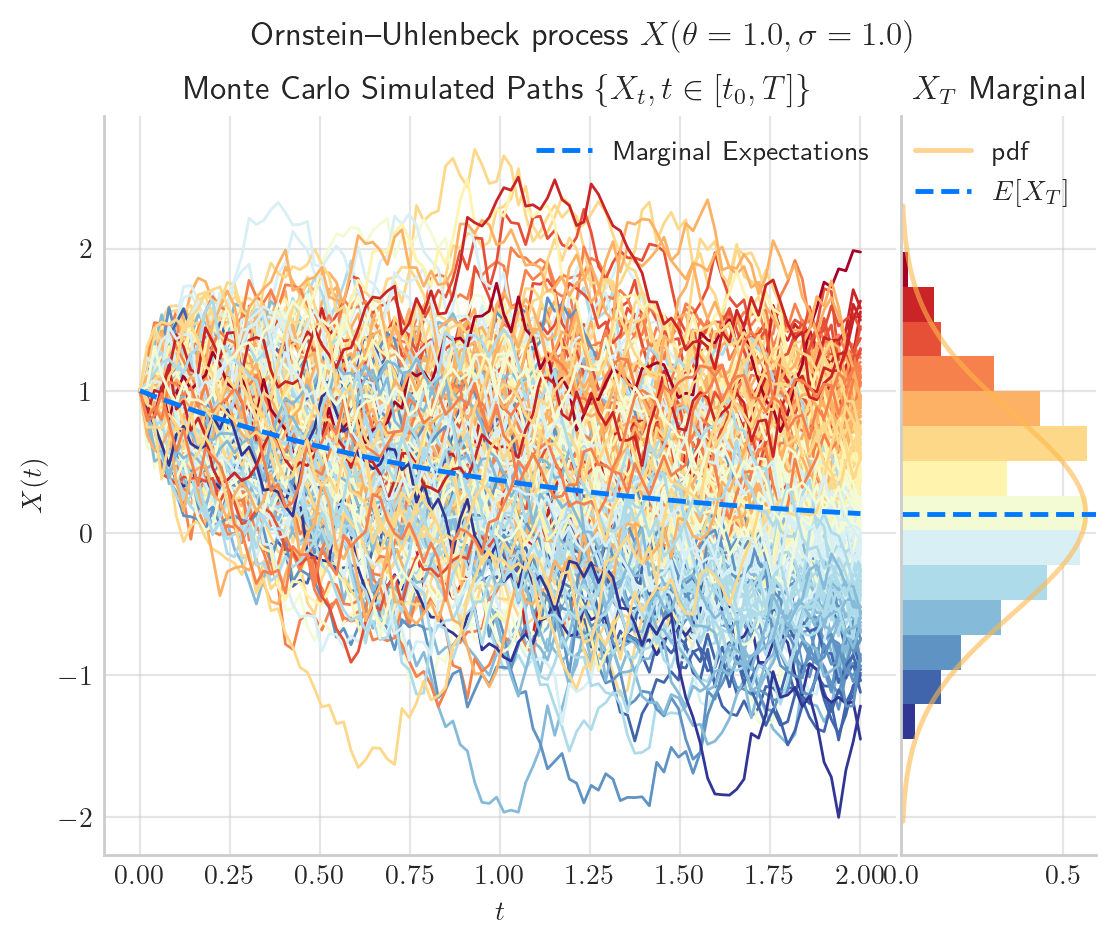

In [22]:
fig =p.draw(n=100, N=200)

### 6. Matérn Kernel

$$
K(x,x') =
\frac{2^{1-\nu}}{\Gamma(\nu)}
\left(\frac{\sqrt{2\nu}d}{\ell}\right)^\nu
K_\nu\left(\frac{\sqrt{2\nu}d}{\ell}\right)
$$

**Intuition**

- Generalisation of RBF kernel
- Smoothness controlled by parameter $$ \nu $$  

**Special cases**

- If $ \nu = 1/2 $ → Ornstein–Uhlenbeck kernel  
- If $ \nu \to \infty $ → Squared exponential kernel  

**Typical paths behaviour**

- Tunable smoothness  

**Interpretation**

> Provides flexible control over roughness of functions

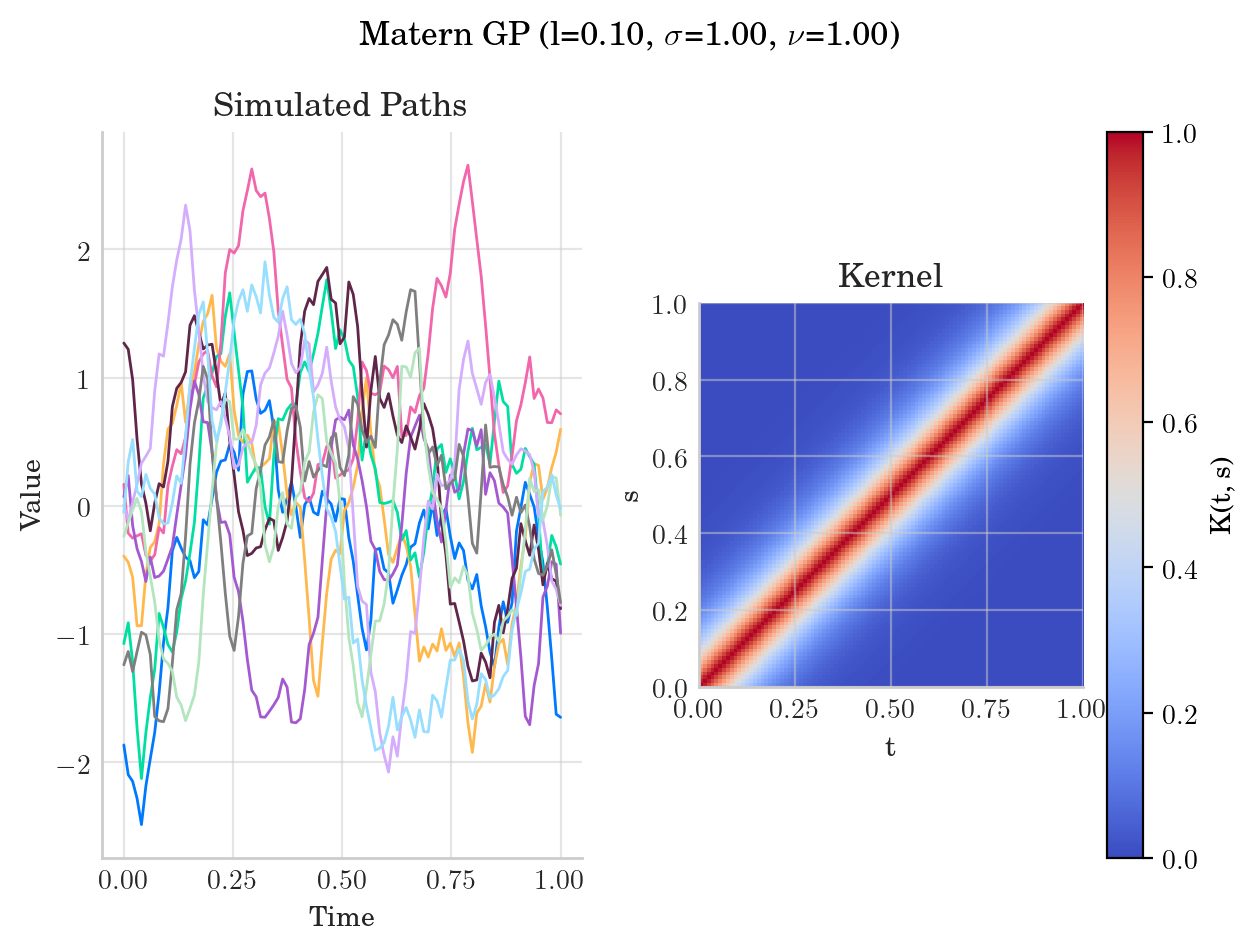

In [23]:
from aleatory.processes import GPMatern
p = GPMatern(sigma=1.0, length_scale=0.1, nu=1.0)
fig = p.plot_paths_and_kernel(n=100, N=10)

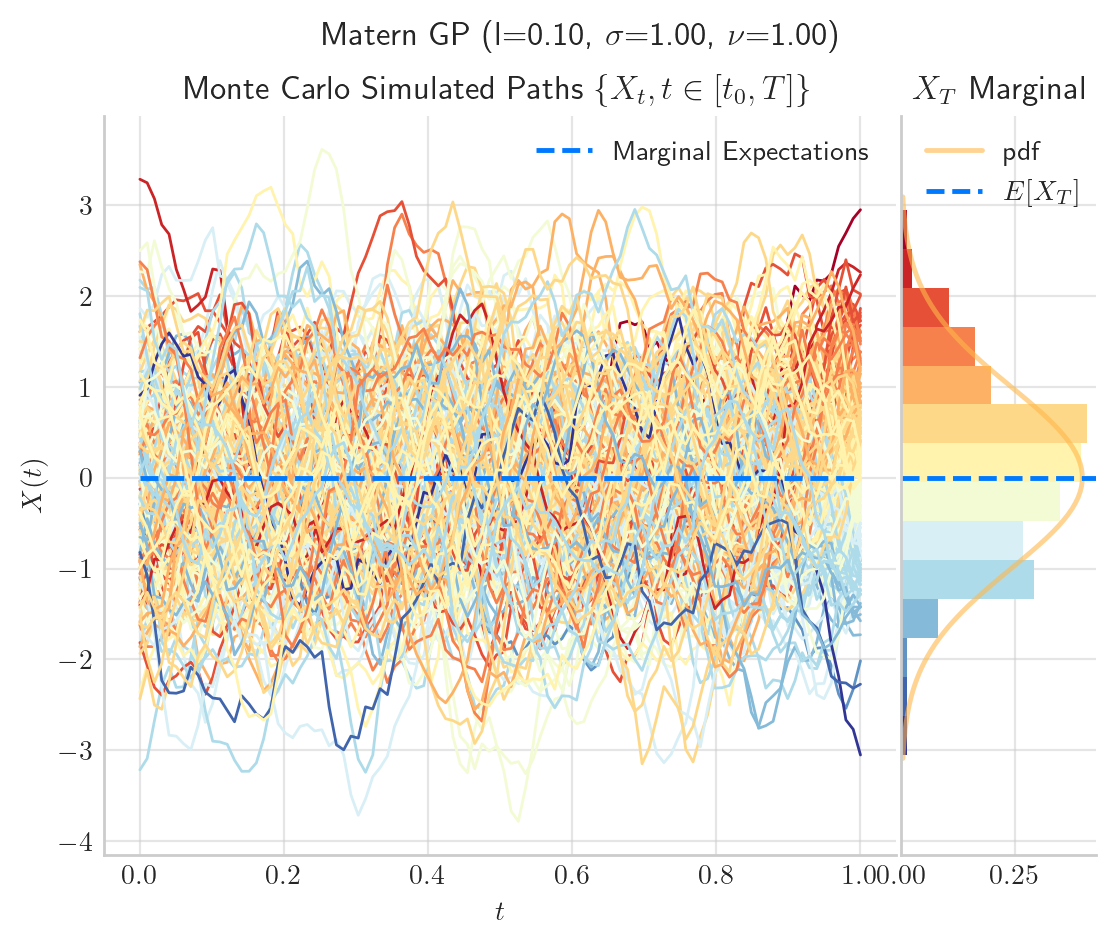

In [24]:
fig = p.draw(n=100, N=200)

### 7. Periodic Kernel

$$
K(x,x') = \exp\left(-\frac{2}{\ell^2}\sin^2\left(\frac{d}{2}\right)\right)
$$

**Intuition**

- Similarity repeats periodically  

**Typical behaviour**

- Smooth periodic functions  

**Interpretation**

> Captures seasonality or cyclic behaviour.
    

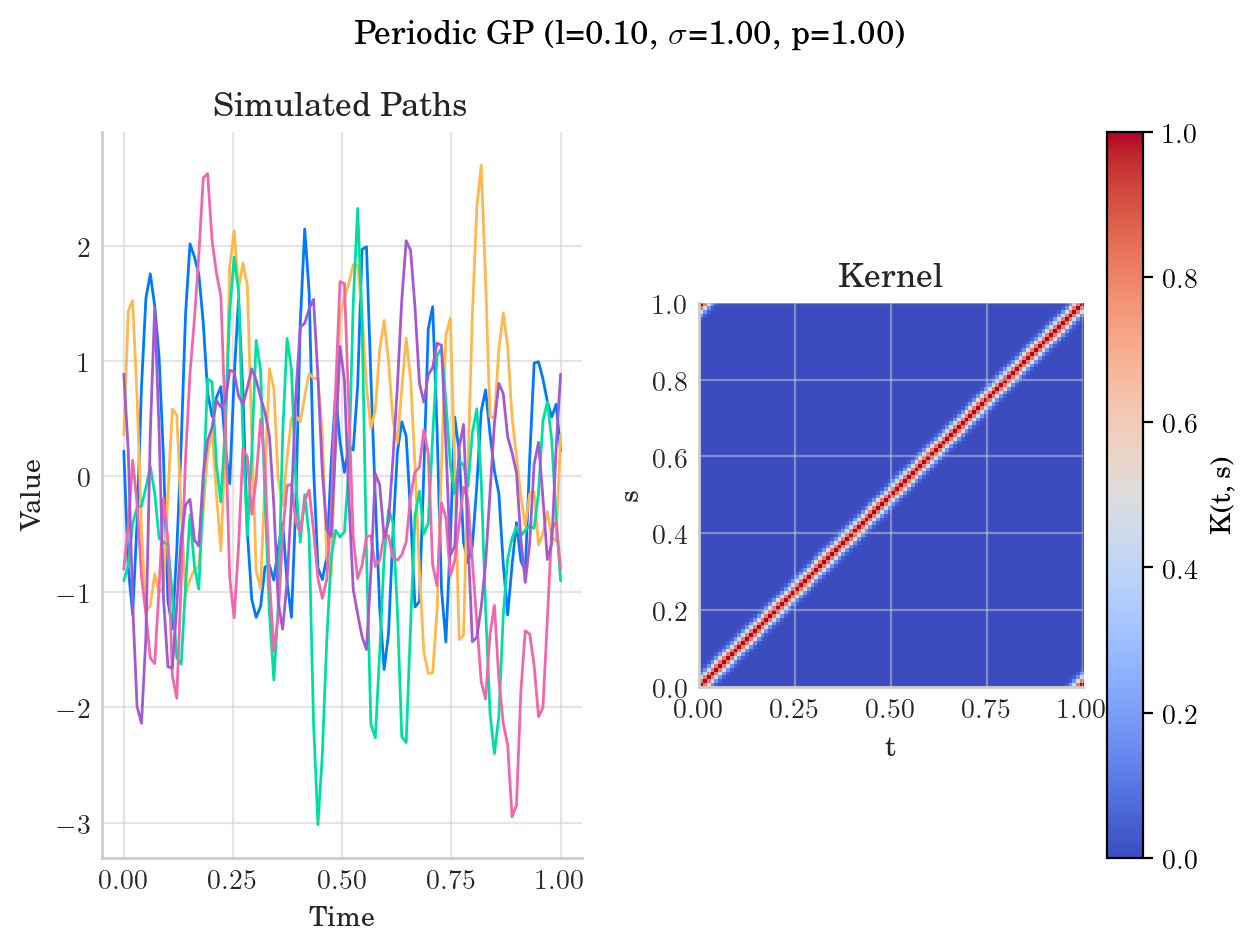

In [25]:
from aleatory.processes import GPPeriodic
p = GPPeriodic(sigma=1.0, length_scale=0.1, period=1.0)
fig = p.plot_paths_and_kernel(n=100, N=5)

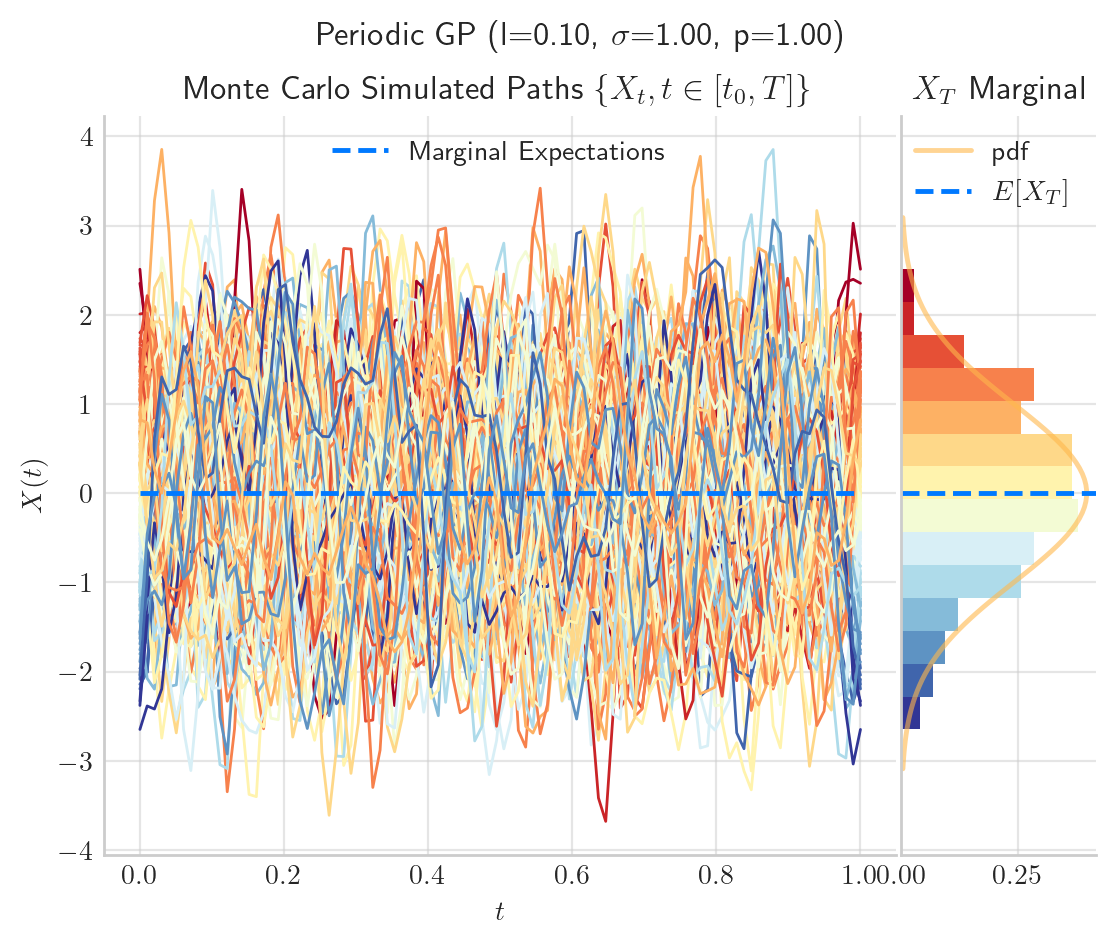

In [26]:
fig = p.draw(n=100, N=200)

### 8. Rational Quadratic Kernel

$$
K(x,x') = (1 + d^2)^{-\alpha}, \quad \alpha \geq 0
$$

**Intuition**

- Mixture of multiple length scales  

**Typical behaviour**

- Functions with both short-term and long-term variation  

**Interpretation**

> Models multi-scale phenomena.



## Combining Kernels

Covariance functions can be combined to model more complex behaviour.

### Addition

$$
K = K_1 + K_2
$$

- Represents the sum of independent effects  



### Multiplication

$$
K = K_1 \cdot K_2
$$

- Represents interaction between structures  



### Example

$$
K = K_{\text{RBF}} + K_{\text{Periodic}}
$$

- Smooth trend + seasonal pattern  



The structural properties of $X$ are encoded in $k$, and in particular:


### Smoothness

**Definition:** Smoothness is characterized by the regularity of sample paths, which can be formalized via mean-square differentiability. The process $X$ is said to be $m$-times mean-square differentiable at $t$ if the derivatives

$$
\frac{\partial^m}{\partial t^m} X(t)
$$

exist in $L^2$. This holds if and only if the covariance function $k(s,t)$ is $2m$-times continuously differentiable in a neighbourhood of $s = t$.

**Intuition:** The local behaviour of $k(s,t)$ near the diagonal $s = t$ determines how rapidly correlations decay between nearby points. If $k$ is very smooth around the diagonal, nearby values of the process are strongly constrained to vary gradually, leading to smooth sample paths. Conversely, lack of regularity in $k$ induces rough or highly oscillatory paths.

**Examples:**

* The squared exponential (RBF) kernel is infinitely differentiable, hence induces sample paths that are almost surely smooth (indeed, $C^\infty$).
* The Matérn class $k_\nu$ yields sample paths that are $\lfloor \nu \rfloor$-times mean-square differentiable; in particular, $\nu = \tfrac{1}{2}$ corresponds to non-differentiable paths.
* The covariance $k(s,t) = \min(s,t)$ (Brownian motion) produces paths that are continuous but nowhere differentiable.


### Variability

**Definition:** Variability is determined by the pointwise variance of the process, given by

$$
\mathrm{Var}(X(t)) = k(t,t).
$$

More generally, the covariance function controls the full second-order structure, including how variance is distributed across the index set and how joint fluctuations occur.

**Intuition:** The magnitude of $k(t,t)$ sets the scale of fluctuations at each point, while the off-diagonal terms $k(s,t)$ determine how these fluctuations co-vary. Larger values of $k(t,t)$ correspond to greater dispersion of the process around its mean.

**Examples:**

* A kernel of the form $k(s,t) = \sigma^2 \tilde{k}(s,t)$ scales the entire process, with $\sigma^2$ directly controlling the marginal variance.
* In heteroscedastic constructions, one may use $k(s,t) = \sigma(s)\sigma(t)\tilde{k}(s,t)$, inducing location-dependent variability.
* For Brownian motion, $k(t,t) = t$, so the variance grows linearly in time.


### Periodicity

**Definition:** A covariance function $k$ is periodic with period $T > 0$ if

$$
k(s + T, t + T) = k(s,t) \quad \text{for all } s,t \in \mathcal{T}.
$$

Equivalently, in the stationary case, periodicity can be expressed as $k(\tau) = k(\tau + T)$ where $\tau = s - t$.

**Intuition:** The covariance structure repeats itself at regular intervals, implying that the dependence between points is invariant under shifts by multiples of the period. This enforces a repeating pattern in the correlation structure of the process.

**Examples:**

* A standard periodic kernel is

$$
k(s,t) = \sigma^2 \exp\left(-\frac{2\sin^2\big(\pi (s-t)/T\big)}{\ell^2}\right),
$$

which enforces exact periodicity with period $T$.

* Trigonometric covariance functions, such as $k(\tau) = \cos(2\pi \tau / T)$, generate perfectly periodic structure.
* Sums/products of periodic and non-periodic kernels allow periodic behaviour with slowly varying amplitudes.


### Mean Reversion

**Definition:** Mean reversion can be formalized through the decay of covariance over time. A process exhibits mean-reverting behaviour if, for fixed $s$,

$$
\lim_{|t - s| \to \infty} k(s,t) = 0,
$$

and the decay occurs at a rate that enforces a characteristic timescale of dependence.

**Intuition:** As the temporal separation increases, the influence of past values on future values diminishes, causing the process to “forget” deviations from the mean and revert toward it. The rate of decay determines how quickly this reversion occurs.

**Examples:**

* The exponential kernel

$$
k(s,t) = \sigma^2 e^{-\lambda |t-s|}
$$

corresponds to the covariance of the Ornstein–Uhlenbeck process, a canonical mean-reverting model.

* More generally, Matérn kernels with finite length scale exhibit mean-reverting behaviour through exponential-type decay.
* In contrast, kernels with slow (e.g., polynomial) decay encode long memory and weaker mean reversion.


### Stationarity

**Definition:** A process $X$ is (weakly) stationary if its covariance function satisfies

$$
k(s,t) = k(s - t) \quad \text{for all } s,t \in \mathcal{T},
$$

i.e., it depends only on the lag $\tau = s - t$, and the mean is constant.

**Intuition:** The statistical structure of the process is invariant under translations of the index set. There is no distinguished location in $\mathcal{T}$; only relative separation matters.

**Examples:**

* The squared exponential and Matérn kernels are stationary since they depend only on $s-t$.
* A kernel like $k(s,t) = \min(s,t)$ is non-stationary, as it depends on absolute time.
* Adding a non-constant variance term (e.g., $k(s,t) = s t$) breaks stationarity.


### Isotropy

**Definition:** When $\mathcal{T} \subset \mathbb{R}^d$, a covariance function is isotropic if there exists a function $\psi : [0,\infty) \to \mathbb{R}$ such that

$$
k(s,t) = \psi(|s - t|),
$$

where $|\cdot|$ is the Euclidean norm.

**Intuition:** The dependence between two points depends only on the distance between them, not on the direction. The process exhibits rotational invariance in its covariance structure.

**Examples:**

* The radial basis function kernel $k(s,t) = \sigma^2 \exp(-|s-t|^2 / (2\ell^2))$ is isotropic.
* Anisotropic kernels take the form $k(s,t) = \exp\big(-(s-t)^\top \Lambda^{-1} (s-t)\big)$, where $\Lambda$ introduces direction-dependent scaling.
* In spatial statistics, isotropic kernels assume uniform behaviour in all directions, while anisotropic ones capture directional effects such as prevailing winds or geological structure.


These examples illustrate how specific functional forms of the covariance function translate directly into qualitative properties of the stochastic process.
